## Homework 6



$\textbf{Please read before running code!}$

Make sure you have the all the python libraries necessary to run the import block below. 

Underneath that cell are the paths to the raw data and reduced data directories. Make sure these correspond to the correct pathing on the device you are running this code. Additionally the reduced directory should have trimmed, overscan subtracted, bias corrected, and flat corrected images of both PG1633+099 and NGC 6823. If you don't have these, please run my code from Homework 5 (`astr_8060_s26/work/brayan/homework/hw5/hw5_brayan.ipynb`)

Note: Please run the cells in order!

In [ ]:
#import block --> Figure out which ones are needed
import numpy as np
from astropy.io import fits
from astropy.time import Time
import pdb
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import rc
from astropy.visualization import hist
from pathlib import Path
from astropy.visualization import ZScaleInterval
import os
from ccdproc import ImageFileCollection
import ccdproc as ccdp
from astropy.modeling import fitting
from astropy.stats import mad_std
from scipy import stats
from astropy import units as u
from photutils.aperture import CircularAperture,CircularAnnulus
from photutils.aperture import aperture_photometry
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from astropy.table import Table
import glob
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [3]:
#initialize path directories 
data_dir = '/home/hernab6/Astr8060_Observational/data/Imaging/'   #raw data directory
reduced_dir = '/home/hernab6/Astr8060_Observational/data/reduced/' 

### Problem 1

CCDs are ideal because over the available dynamic range, they are very linear (that is,
one photon produces on electron).Test the linearity of the CCD using the sequence of
exposures labeled linearity test in the log. Make a plot of ADU versus time and determine
whether the chip is linear to the full 16 bits of the A-D converter. What you care about
here is whether the signal stays linear with exposure time as the flux in the peak pixel
approaches the $2^{16}$ ADU limit.

$\textbf{Logical Rundown}:$ For this problem I identified the largest/brightest star as it would saturate the pixels the most. Then I zoomed in the star of a very small region and played around with the region of interest (roi) until the 128 second exposure was really close to $2^{16}$.

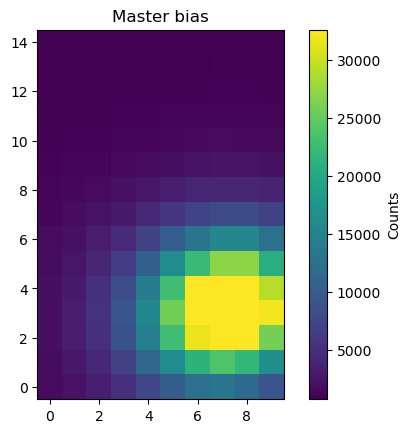

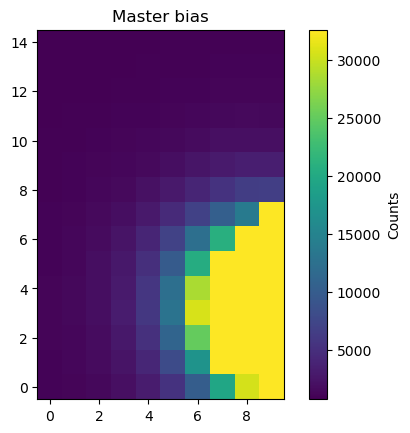

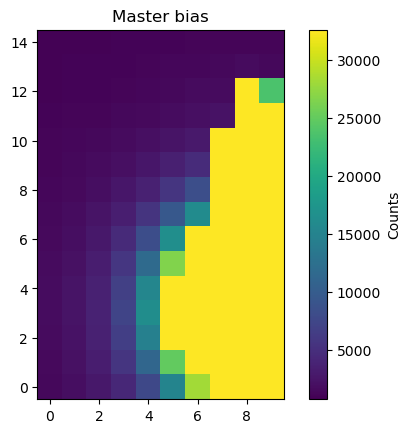

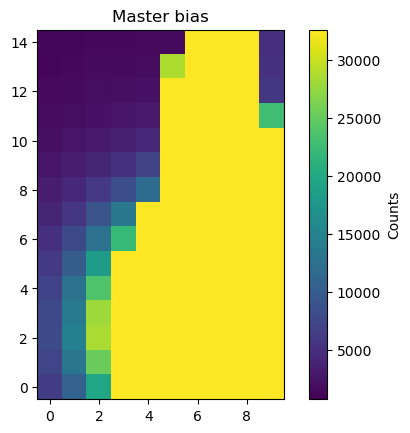

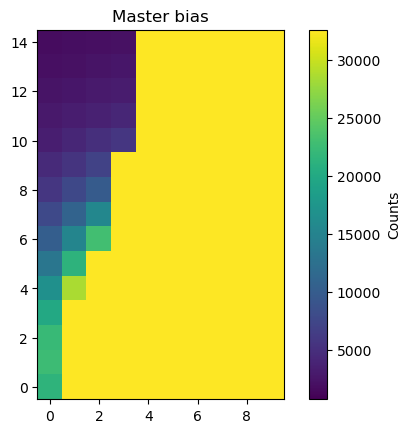

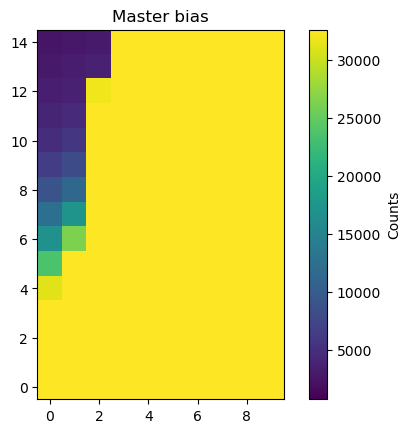

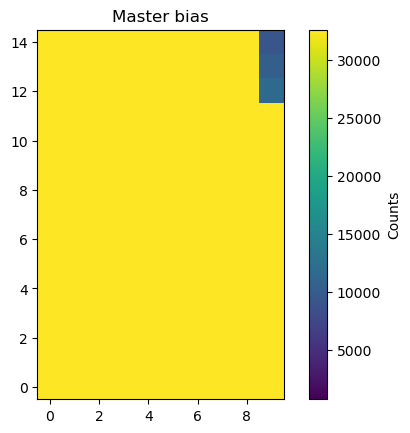

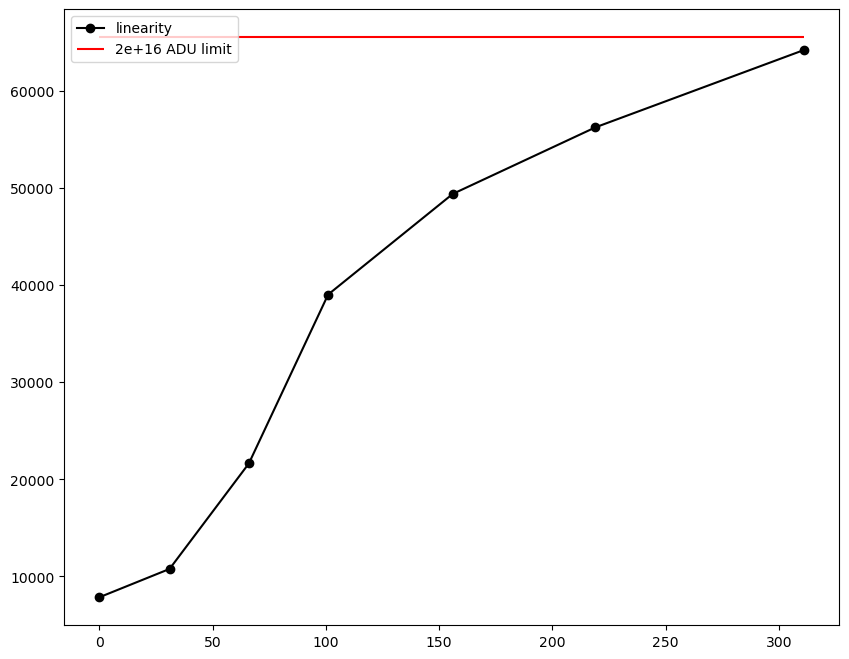

In [ ]:
#grab linearity test 
indices = np.arange(74,81)                # indices in the log corresponding to linearity test
#initialized file directory
folder = Path(data_dir) #pulling from the reduced directory insead of the raw data

linearity_files = []
for i in indices:
    filename = f"a{i:03d}.fits"
    filepath = folder / filename
    if filepath.exists():
        linearity_files.append(filepath)

# overscan subtract, trim, and master bias correct the science exposures for NGC6823 (otz) and save files
interval=ZScaleInterval()
t_arr=[]
mean_arr=[]
for i,file in enumerate(linearity_files):
    data = fits.getdata(file)
    # define a slightly larger search region where the star is
    #roi = data[600:610, 575:590]

    roi=data[1710:1725, 665:675]
    hdr = fits.getheader(file)
    time=hdr['DATE-OBS']
    mean=np.mean(roi)
    mean_arr.append(mean)
    t = Time(time, format='isot', scale='utc').mjd
    t_arr.append(t)
    vmin_master, vmax_master= interval.get_limits(data)
    #plt.imshow(data, vmin=vmin_master, vmax=vmax_master, origin='lower', cmap='viridis')
    #plt.colorbar(label="Counts")
    #plt.title(f"{file}")
    #plt.show()
    if i==0:
        vmin_master_roi, vmax_master_roi= interval.get_limits(roi)
    plt.imshow(roi, vmin=vmin_master_roi, vmax=vmax_master_roi, origin='lower', cmap='viridis')
    plt.colorbar(label="Counts")
    plt.title("Master bias")
    plt.show()

t_arr = np.array(t_arr)
t_arr = (t_arr - t_arr[0]) * 86400

fig, ax= plt.subplots(1, figsize=(10, 8))
plt.plot(t_arr, mean_arr, '-o', color='k', label='linearity')
plt.hlines(y=2**16, xmin=t_arr[0], xmax=t_arr[-1], color='red', label='2e+16 ADU limit')

plt.legend()
#plt.tight_layout()
plt.show()



$\textbf{Results (Problem 1):}$ Evidently the region I chose was not the best since the relation was not entirely linear but I think it was good enough since I took a long time getting what I have plotted. Plus, Jessie said it was good enough hehe

### Problem 2

Use photutils to perform aperture photometry on three (non saturated) stars in the
PG1633+099 standard field: a really faint one, a medium bright one, and a bright one.
Perform aperture photometry using at least 5 aperture sizes from very small to very large
and make a plot that reproduces the one from Howell Figure 5.7 showing S/N as a function
of aperture radius. What is a good aperture size to use for this dataset?

$\textbf{Logical Rundown}:$ To calculate the SNR for 3 stars, I used the following equations: 
$$S/N = \frac{S_{source}}{\sqrt{S_{Source} \cdot N_{pixels}((\frac{S_{Background}}{A_{Annulus}})^2-N_{Read}^2)}}$$

where,
$$S_{Source}= S_{Aperture}-\frac{S_{Background}}{A_{Annulus}} A_{Aperture}$$
$$N_{pixels} \equiv A_{Aperture}$$

and $A$ indicates area, $S$ indicates signal from the aperture photometry sum, $N_pixels$ are the number of pixels and $N_{Read}$ is the read noise. The read noise was determined from the previous homework (HW 5).

In [452]:
std_field_V= glob.glob(reduced_dir+"a082otzf.fits")
hdu=fits.open(std_field_V[0])
image=fits.getdata(std_field_V[0])
print(repr(hdu[0].header))

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 2048                                                  
NAXIS2  =                 2048                                                  
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
DATE    = '2009-09-15T15:56:30' / Date FITS file was generated                  
IRAF-TLM= '09:56:29 (15/09/2009)' / Time of last modification                   
DATAMIN =           0.000000E0 / Minimum data value                             
DATAMAX =           6.553500E4 / Maximum data value                             
OBJECT  = 'SERVICE '           / Name of the object observed                    
DATE-OBS= '2009-06-23T04:03:57.000' / Date and time of observation              
TIMESYS = 'UTC     ' / Defau

In [453]:
x1 = 615
x2 = 524
x3 = 494
y1 = 1710
y2 = 600
y3 = 1470
positions = [(x1,y1),(x2,y2),(x3,y3)]

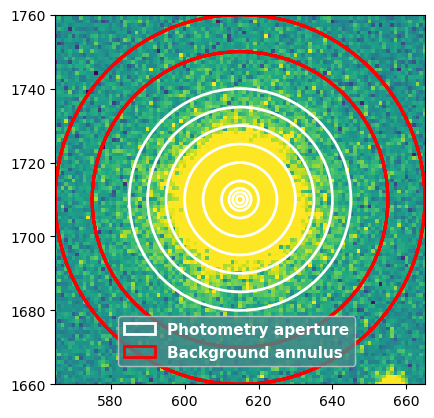

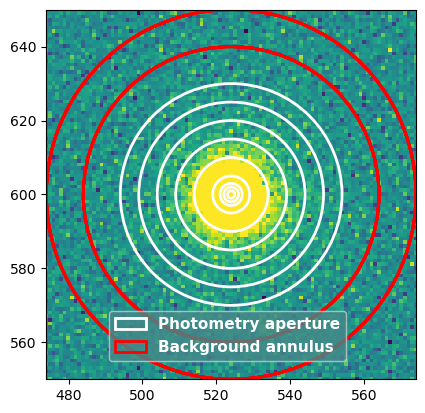

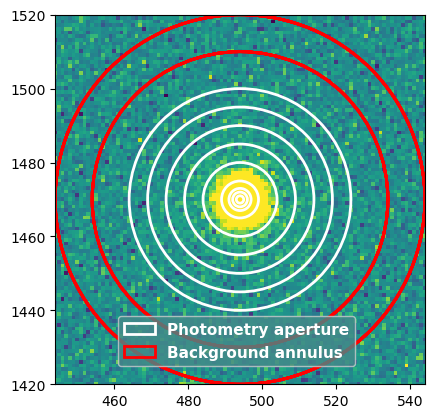

In [455]:
from astropy.visualization import simple_norm
from photutils.aperture import CircularAnnulus, CircularAperture

r_arr=[1,2,3,5,10, 15, 20, 25, 30]

for i in range(3):

    for j,radius in enumerate(r_arr):
        aperture = CircularAperture(positions, r=radius)
        annulus_aperture = CircularAnnulus(positions, r_in=40, r_out=50)

        vmin_master, vmax_master= interval.get_limits(image)
        plt.imshow(image, vmin=vmin_master, vmax=vmax_master, origin='lower', cmap='viridis')
        plt.xlim(positions[i][0]-50, positions[i][0]+50)
        plt.ylim(positions[i][1]-50, positions[i][1]+50)

        ap_patches = aperture.plot(color='white', lw=2,
                                label='Photometry aperture')
        ann_patches = annulus_aperture.plot(color='red', lw=2,
                                            label='Background annulus')
        handles = (ap_patches[0], ann_patches[0])
        plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                handles=handles, prop={'weight': 'bold', 'size': 11})
    plt.show()
    


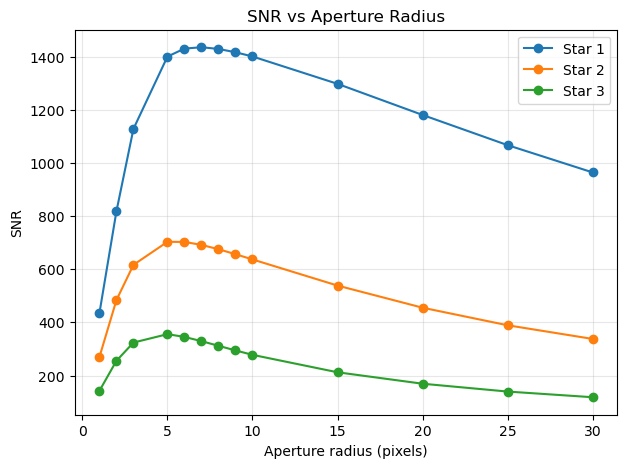

In [462]:
r_arr=[1,2,3,5,6,7,8,9,10, 15, 20, 25, 30]
t_exp=60
# Background annulus: same for all stars
annulus = CircularAnnulus(positions, r_in=40, r_out=50)

#read noise
read_noise=12.36 # e- <-- this was calculated from HW 5!
gain= 1.53 # e-/ADU <-- also calculated from HW 5

read_noise_ADU=read_noise/gain

snr = np.zeros((len(positions), len(r_arr)))

for j, radius in enumerate(r_arr):
    aperture = CircularAperture(positions, r=radius)

    # Total counts inside each aperture
    phot_table = aperture_photometry(image, aperture)
    aper_sum = np.array(phot_table['aperture_sum'])

    bkg_phot = aperture_photometry(image, annulus)
    ann_sum = np.array(bkg_phot["aperture_sum"])

    # Geometric areas from photutils
    aper_area = aperture.area
    ann_area = annulus.area

    # Background per pixel from annulus sum
    bkg_mean_per_pix = ann_sum / ann_area

    # Background scatter per pixel from annulus pixels
    bkg_std_per_pix = np.zeros(len(positions))


    # Background-subtracted source counts
    net_counts = aper_sum - bkg_mean_per_pix * aper_area


    # Background noise in the source aperture
    n_pixels= aper_area

    snr[:, j] = (net_counts) / np.sqrt((net_counts)+ n_pixels*((bkg_mean_per_pix**2) + read_noise_ADU**2)) #Dark current was ignored since in HW4 I

# Plot SNR vs aperture radius for each star
plt.figure(figsize=(7, 5))
for i in range(len(positions)):
    plt.plot(r_arr, snr[i], marker='o', label=f'Star {i+1}')

plt.xlabel('Aperture radius (pixels)')
plt.ylabel('SNR')
plt.title('SNR vs Aperture Radius')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

$\textbf{Results (Problem 2):}$ I think I chose 3 very bright stars, they have relatively different fluxes from each other but my dimmest star was still too bright. Either way I think the stars I chose were fine since they display the same pattern/trend from Figure 5.7 in Howell. From this plot I am able to justify using an aperture radius of 5 pixels for the rest of my analysis since that maximizes the signal-to-noise ratio.

### Problem 3

Identify the standard stars in the PG1633+099 frame from Landolt (1992)

$\textbf{Logical Rundown}:$ I compared the image from Landolt's 1992 paper (on page 71) to my images and identify the labelled stars A,B,C,and D from the Landolt image in my 

In [753]:
std_field_U= glob.glob(reduced_dir+"a082otzf.fits")
hdu=fits.open(std_field_U[0])
image=fits.getdata(std_field_U[0])


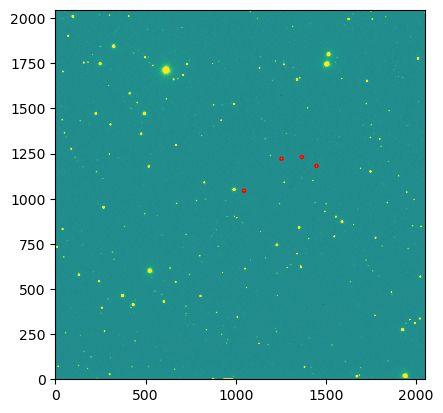

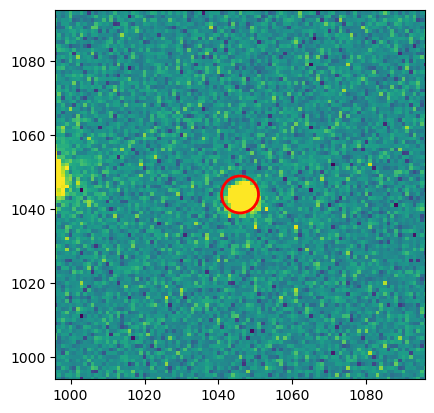

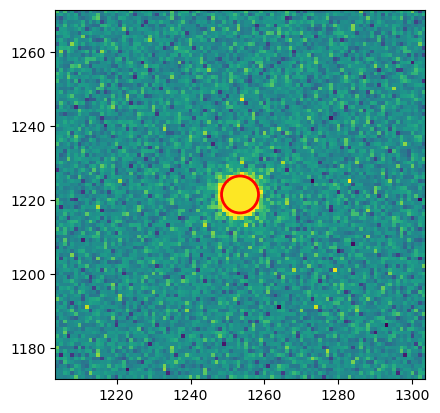

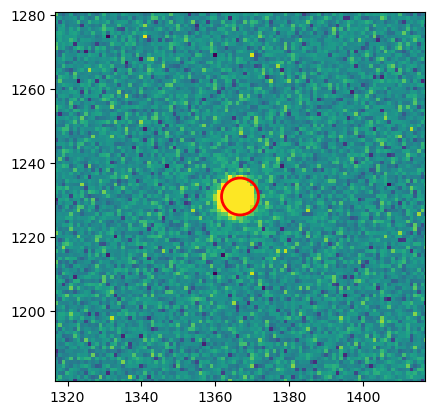

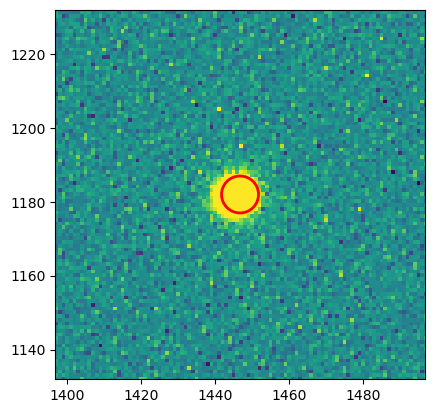

In [754]:
landolt_positions = [(1045.8392,1044), (1253.3862,1221.4621), (1366.6717, 1230.92), (1446.7242, 1181.96)] # these were selected through visual inspection

aperture = CircularAperture(landolt_positions, r=5)

vmin, vmax= interval.get_limits(image)
plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')


ap_patches = aperture.plot(color='red', lw=2,
                        label='Photometry aperture')

plt.show()

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')

        plt.show()


$\textbf{Results (for Problem 3):}$ Stars A,B,C,D in PG1633+099 in Landolt's 1992 paper were found!

### Problem 4

Extract instrumental magnitudes for all of your standard stars using an approach that
you’ve advocated for as best you can in the questions above

$\textbf{Logical Rundown}:$ I took the magnitude equation from the `aperture.ipynb` lecture notebook, except I think the signal that is input into the $log_{10}$ function, $(T-AB)$ and divided by the exposure time since it should be a flux. 

In [762]:

# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")


Instrumental Magnitude: -5.614655537591242
Instrumental Magnitude: -7.1095170818361115
Instrumental Magnitude: -6.685006919304853
Instrumental Magnitude: -7.819307192374843


## Problem 5

Plot your standard star instrumental magnitudes versus their airmass (or since you have
many different standard stars taken at different airmass, plot the difference between the
accepted magnitude and your instrumental magnitude versus airmass). Use one of the
linear fitting routines in Python to do a least squares fit to find and plot the extinction
coefficients at each filter. You can find their magnitudes and colors in Landolt (1992).

$\textbf{Logical Rundown}:$ First I had to caluclate all the intrumental magnitudes for different observations of PG1633+099 where there were different airmasses ($\chi$) for each of the 5 filters ($U,B,V,R,I$). I saved them within nested lists, definitely should have used dictionaries but did not want to wrap my brain around that. There are many cells that were ran to collect all of them since I had to slightly change the pixel positions because of the dithering between exposures. I will submit this code with those cells collapsed but feel free to uncollapse (but beware!)

Then I made the plots for the difference between the accepted magnitude and your instrumental magnitude versus airmass and fit them using a 1 degree polynomial where the slope is the extinction coefficient and the y-intercept is the zero point.


In [ ]:
#These lists will store the information I need (I should've used a dictionary)
Star_A_U= []
Star_A_B= []
Star_A_V= []
Star_A_R= []
Star_A_I= []

Star_B_U= []
Star_B_B= []
Star_B_V= []
Star_B_R= []
Star_B_I= []

Star_C_U= []
Star_C_B= []
Star_C_V= []
Star_C_R= []
Star_C_I= []

Star_D_U= []
Star_D_B= []
Star_D_V= []
Star_D_R= []
Star_D_I= []

U_list= [Star_A_U, Star_B_U, Star_C_U, Star_D_U]
B_list= [Star_A_B, Star_B_B, Star_C_B, Star_D_B]
V_list= [Star_A_V, Star_B_V, Star_C_V, Star_D_V]
R_list= [Star_A_R, Star_B_R, Star_C_R, Star_D_R]
I_list= [Star_A_I, Star_B_I, Star_C_I, Star_D_I]


### For the first epoch of observations: X=1.18

U=a082.fits \
B=a084.fits \
V=a085.fits \
R=a087.fits \
I=a089.fits 


### U Filter

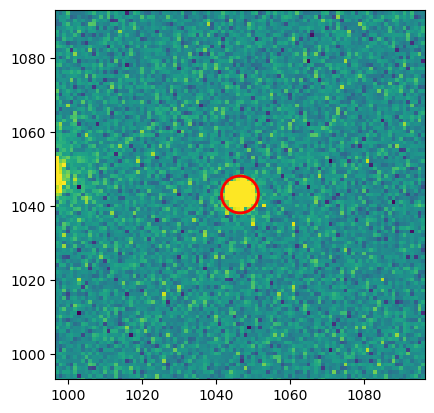

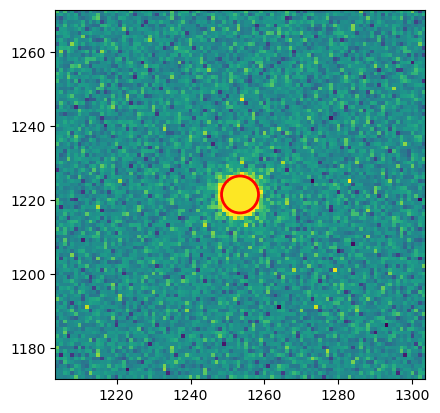

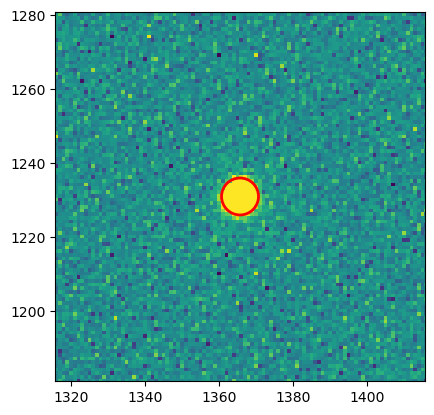

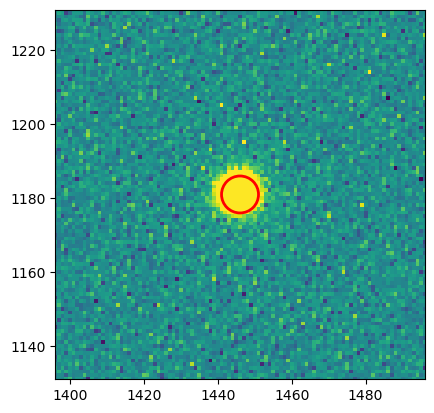

In [527]:
std_field_U= glob.glob(reduced_dir+"a082otzf.fits")
hdu=fits.open(std_field_U[0])
image=fits.getdata(std_field_U[0])

landolt_positions = [(1046.5,1043.1), (1253.3862,1221.4621), (1365.6717, 1230.92), (1446, 1181)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [528]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    U_list[i].append(m)

Instrumental Magnitude: -5.6490331909249045
Instrumental Magnitude: -7.1095170818361115
Instrumental Magnitude: -6.705976104180092
Instrumental Magnitude: -7.840581239066403


### B Filter

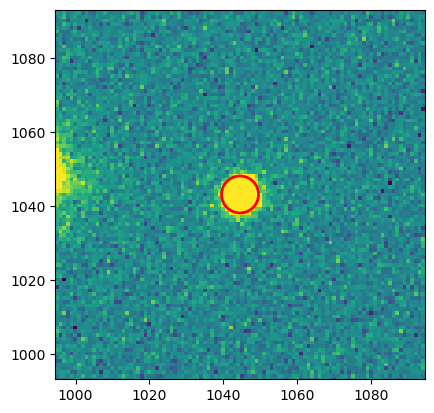

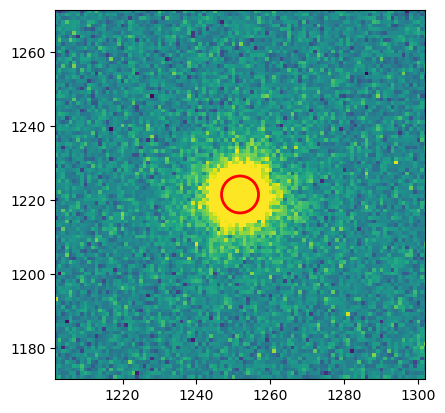

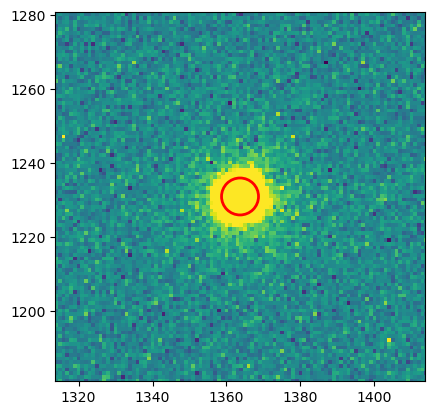

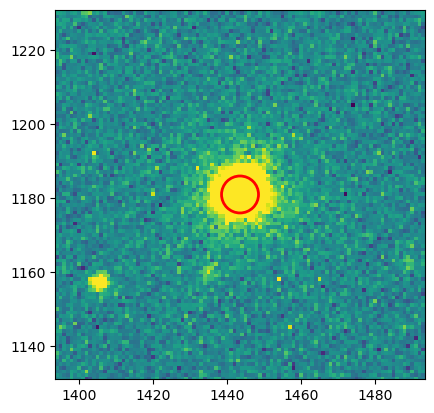

In [538]:
std_field_B= glob.glob(reduced_dir+"a084otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(1044.5,1043.1), (1251.7862,1221.4621), (1363.6717, 1230.92), (1443.5, 1181)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [539]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    B_list[i].append(m)

Instrumental Magnitude: -8.545751893808557
Instrumental Magnitude: -10.65731624648464
Instrumental Magnitude: -10.352169392944809
Instrumental Magnitude: -10.417825244099756


### V Filter

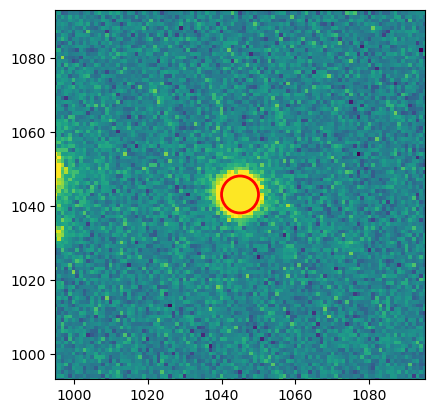

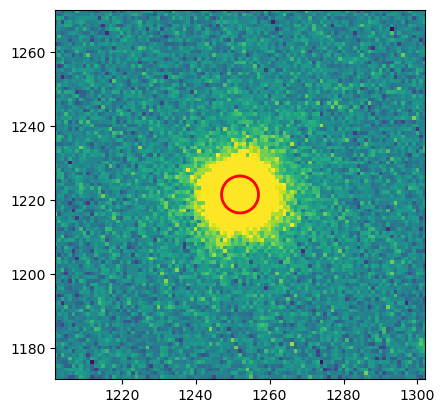

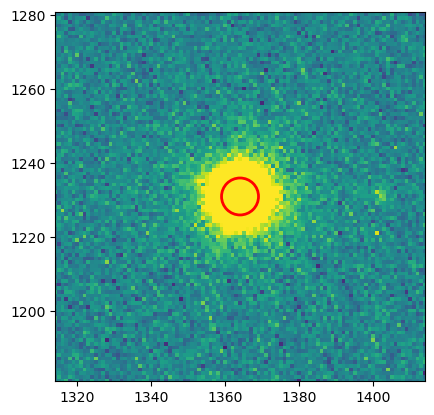

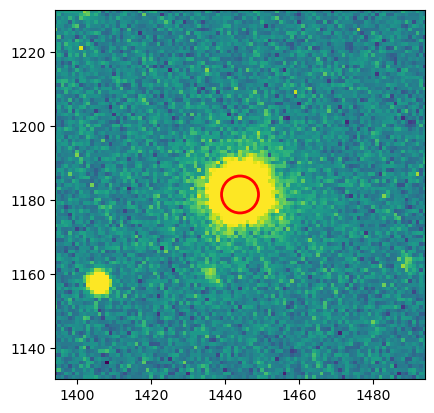

In [547]:
std_field_B= glob.glob(reduced_dir+"a085otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(1045,1043.1), (1252,1221.4621), (1364, 1230.92), (1444, 1181.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [548]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    V_list[i].append(m)

Instrumental Magnitude: -9.44680085784704
Instrumental Magnitude: -11.723259834588436
Instrumental Magnitude: -11.459806471820793
Instrumental Magnitude: -11.036171954110202


### R Filter

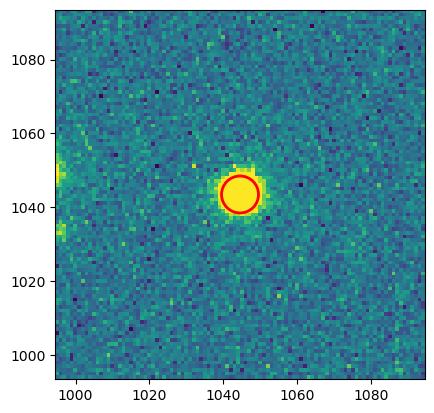

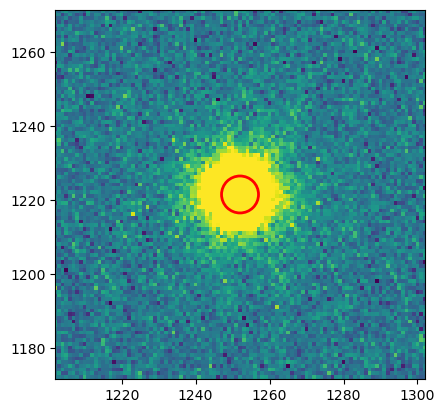

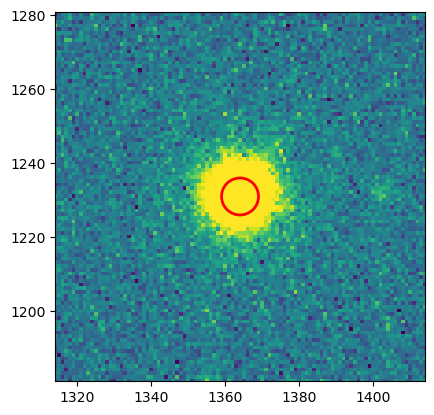

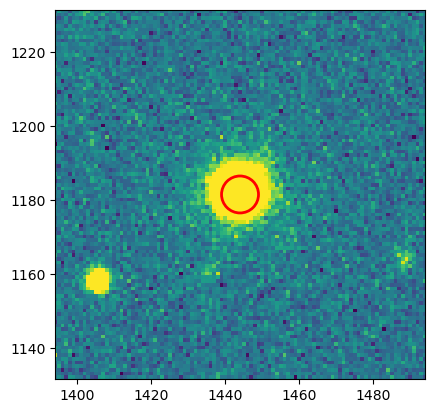

In [556]:
std_field_B= glob.glob(reduced_dir+"a087otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(1044.5,1043.5), (1252,1221.4621), (1364, 1230.92), (1444, 1181.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [557]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    R_list[i].append(m)

Instrumental Magnitude: -9.953362413952476
Instrumental Magnitude: -12.318643884146281
Instrumental Magnitude: -12.089346596767065
Instrumental Magnitude: -11.35844006788427


### I filter

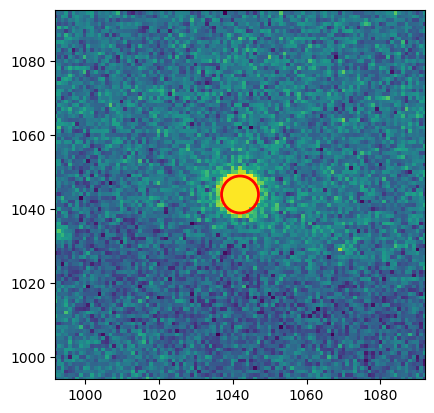

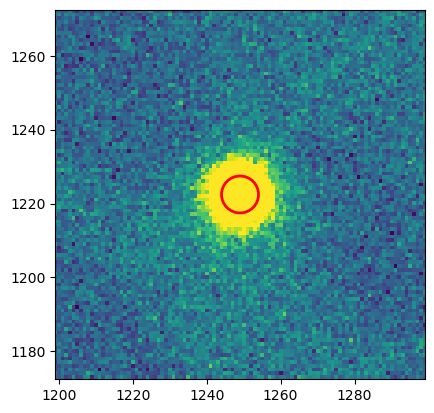

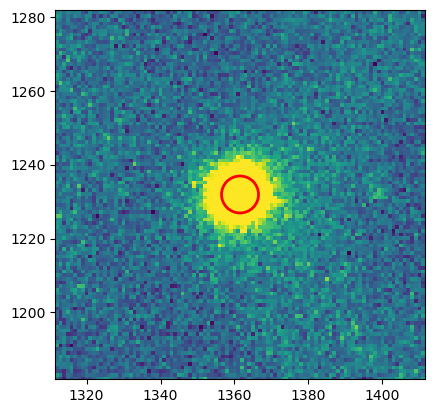

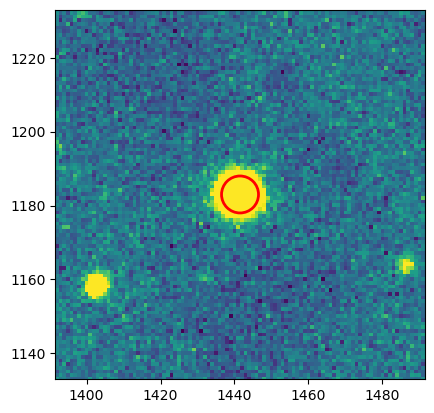

In [565]:
std_field_I= glob.glob(reduced_dir+"a089otzf.fits")
hdu=fits.open(std_field_I[0])
image=fits.getdata(std_field_I[0])

landolt_positions = [(1042,1044), (1249,1222.4621), (1361.5, 1231.92), (1441.5, 1183)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [566]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    I_list[i].append(m)

Instrumental Magnitude: -9.988796115645108
Instrumental Magnitude: -12.356271482234654
Instrumental Magnitude: -12.142446656012766
Instrumental Magnitude: -11.19459498211655


### 2nd Epoch: X=1.24
U: a131.fits
B: a133.fits
V: a135.fits
R: a137.fits
I: a139.fits

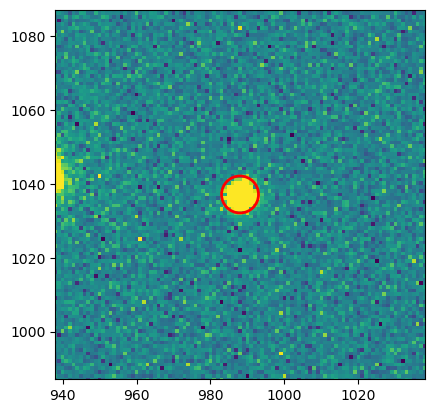

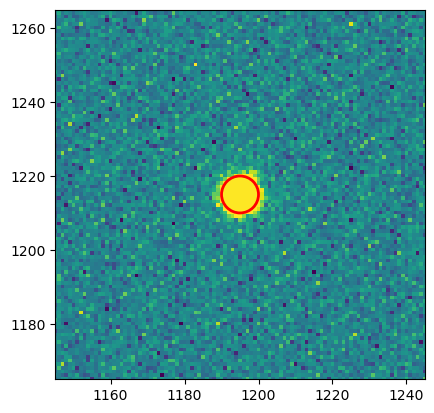

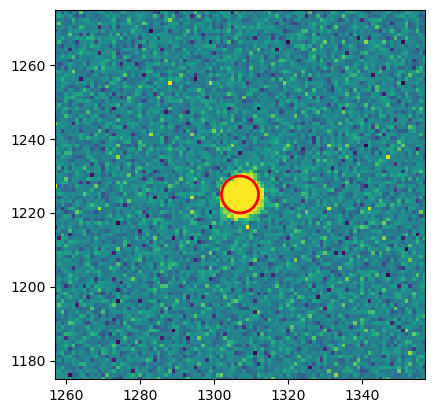

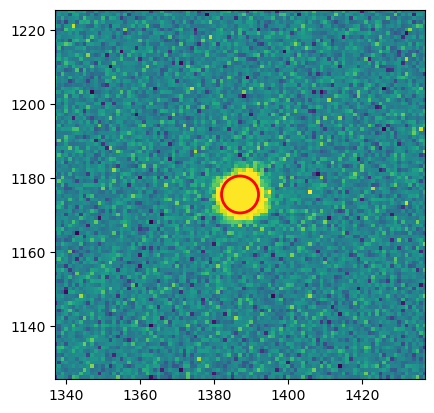

In [530]:
std_field_B= glob.glob(reduced_dir+"a131otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(988,1037.1), (1195,1215), (1307, 1224.92), (1387, 1175.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [531]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    U_list[i].append(m)

Instrumental Magnitude: -5.5660287139192395
Instrumental Magnitude: -7.07641082684318
Instrumental Magnitude: -6.6530793993187185
Instrumental Magnitude: -7.801168038368341


### B Filter

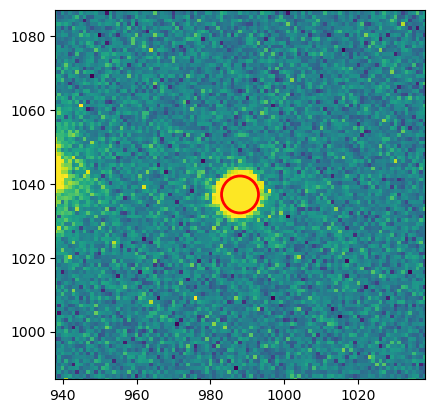

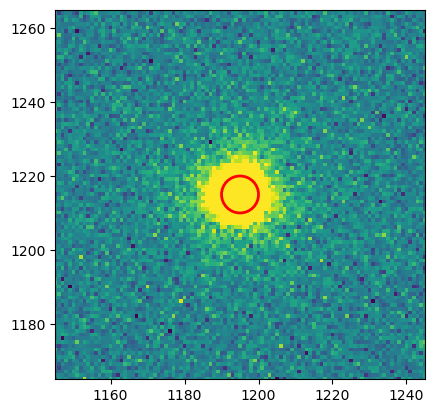

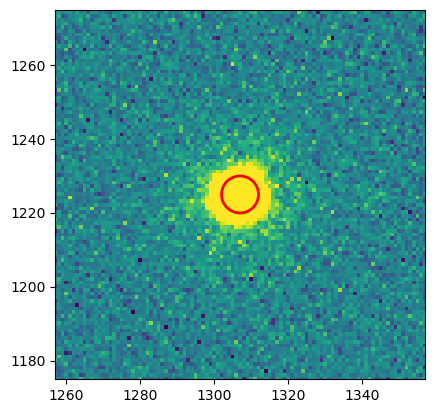

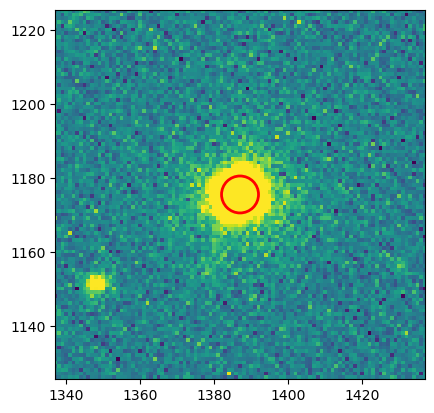

In [540]:
std_field_B= glob.glob(reduced_dir+"a133otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(988,1037.1), (1195,1215), (1307, 1224.92), (1387, 1175.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [541]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    B_list[i].append(m)

Instrumental Magnitude: -8.476528777427108
Instrumental Magnitude: -10.586191834143646
Instrumental Magnitude: -10.286735853101447
Instrumental Magnitude: -10.35226037889051


### V Filter

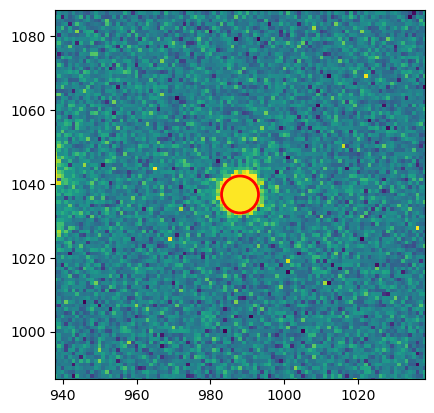

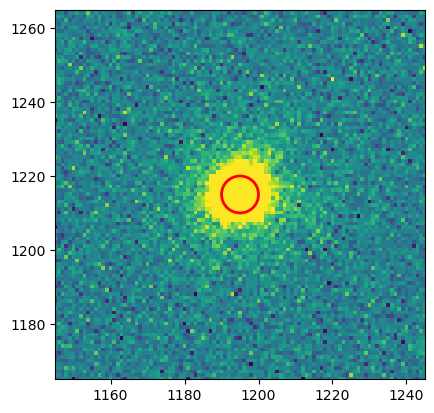

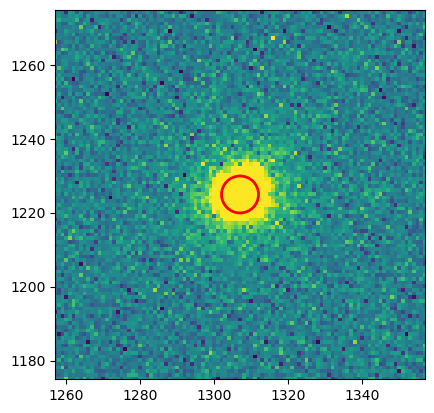

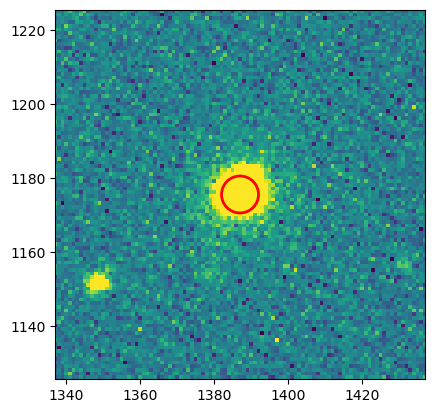

In [549]:
std_field_B= glob.glob(reduced_dir+"a135otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(988,1037.1), (1195,1215), (1307, 1224.92), (1387, 1175.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [550]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)
    V_list[i].append(m)
    print(f"Instrumental Magnitude: {m}")

Instrumental Magnitude: -9.454018612021063
Instrumental Magnitude: -11.721842858687193
Instrumental Magnitude: -11.467469418502274
Instrumental Magnitude: -11.045838434343692


### R Filter

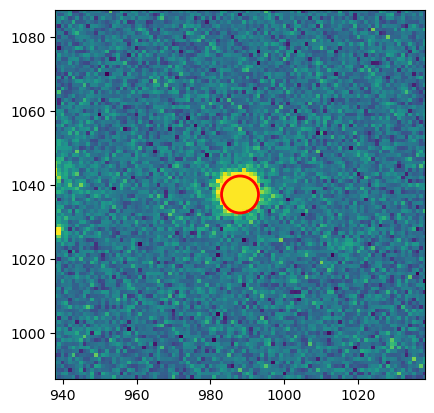

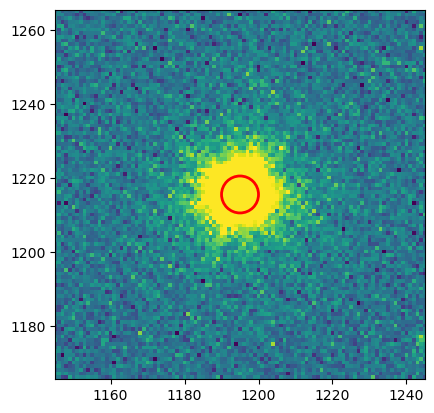

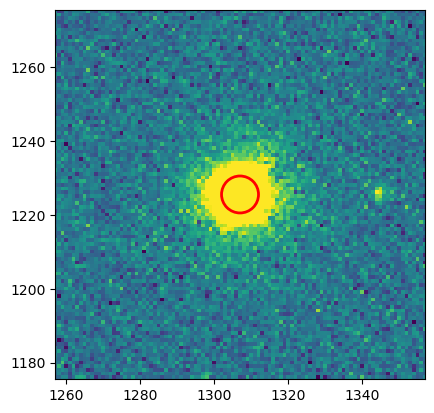

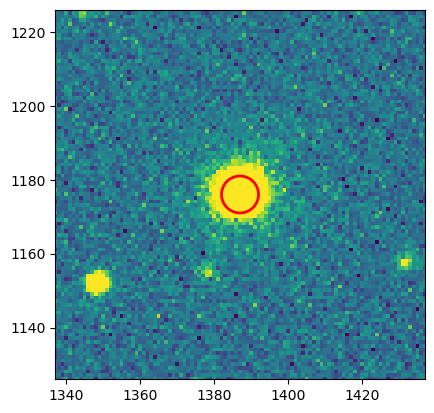

In [558]:
std_field_B= glob.glob(reduced_dir+"a137otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(988,1037.5), (1195,1215.5), (1307, 1225.5), (1387, 1176)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [559]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    R_list[i].append(m)

Instrumental Magnitude: -9.975844504111187
Instrumental Magnitude: -12.343252384008272
Instrumental Magnitude: -12.116121476905448
Instrumental Magnitude: -11.401295337014858


### I Filter

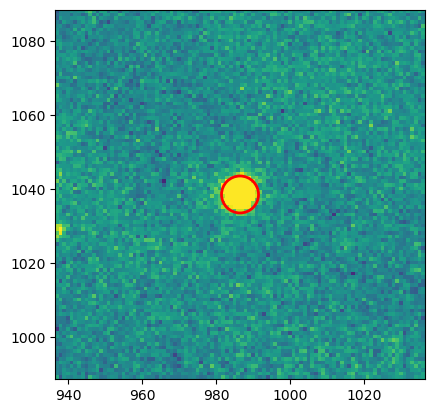

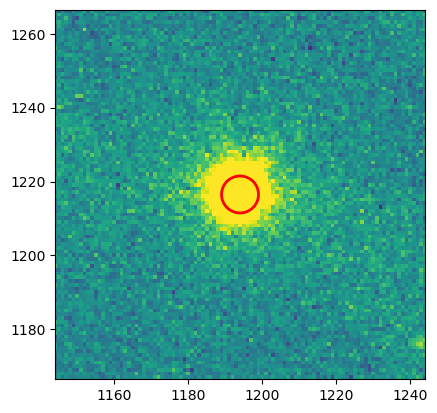

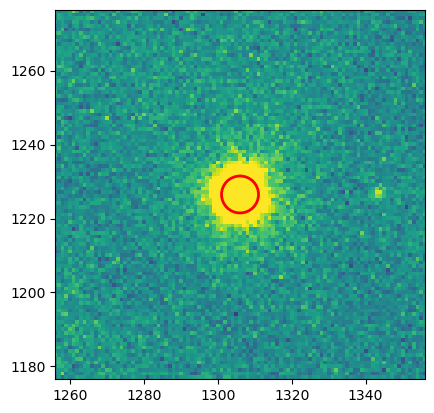

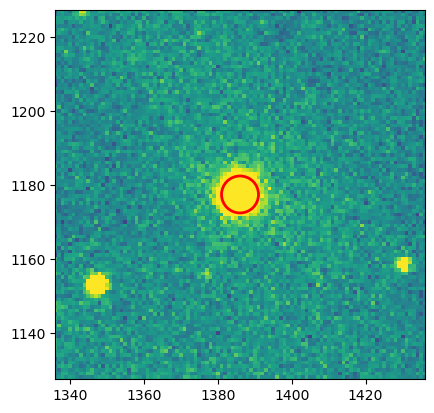

In [567]:
std_field_B= glob.glob(reduced_dir+"a139otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(986.5,1038.5), (1194,1216.5), (1306, 1226.5), (1386, 1177.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [568]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    I_list[i].append(m)

Instrumental Magnitude: -10.027219269506897
Instrumental Magnitude: -12.360925889188138
Instrumental Magnitude: -12.174602954959635
Instrumental Magnitude: -11.22001230721823


### 3rd Epoch: X~1.51
U: a202.fits \
B: a204.fits \
V: a206.fits \
R: a208.fits \
I: a210.fits 

### U Filter

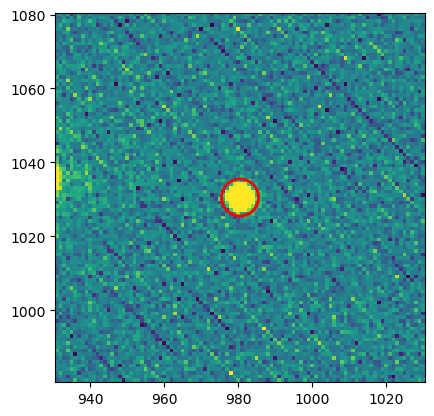

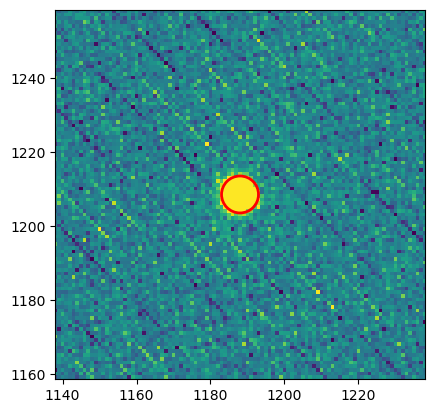

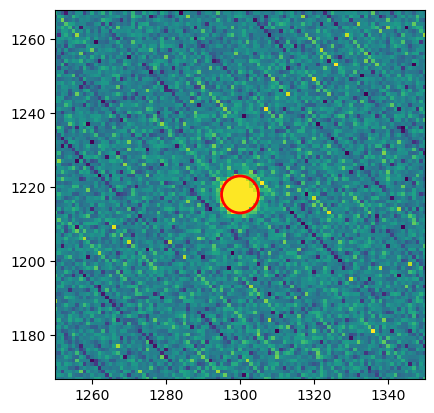

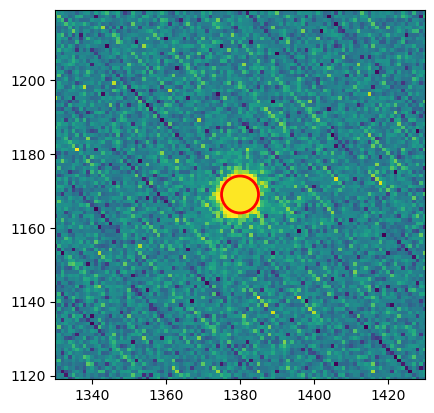

In [ ]:
std_field_B= glob.glob(reduced_dir+"a202otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])B_list[i][3]=m

landolt_positions = [(980.5,1030.5), (1188,1208.5), (1300, 1218), (1380, 1169)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [534]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    U_list[i].append(m)

Instrumental Magnitude: -5.507536019330139
Instrumental Magnitude: -7.008224260141978
Instrumental Magnitude: -6.609453354036539
Instrumental Magnitude: -7.734415808060199


### B Filter


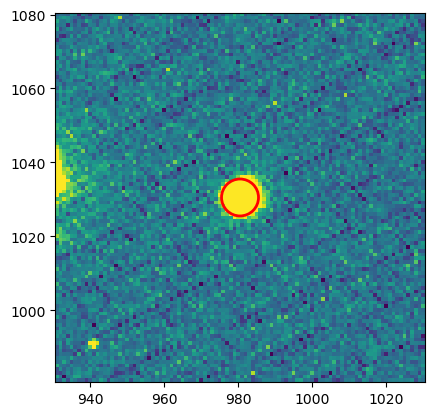

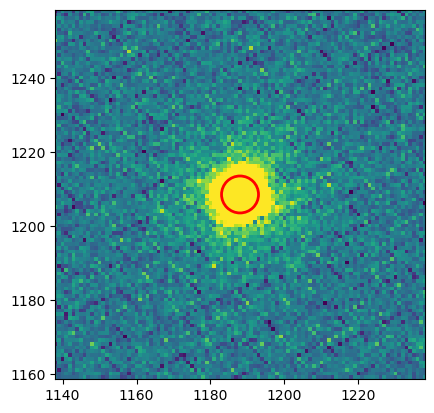

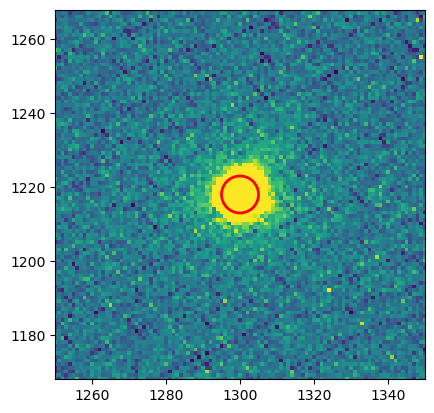

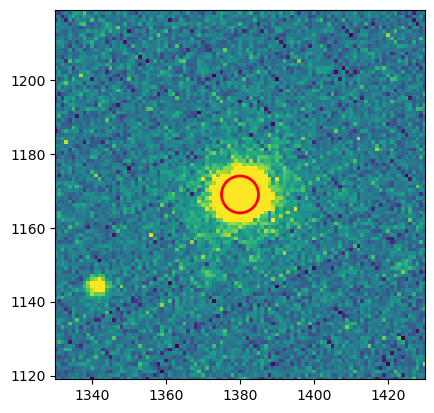

In [542]:
std_field_B= glob.glob(reduced_dir+"a204otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(980.5,1030.5), (1188,1208.5), (1300, 1218), (1380, 1169)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [543]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    B_list[i].append(m)

Instrumental Magnitude: -8.448750323687522
Instrumental Magnitude: -10.573872172255491
Instrumental Magnitude: -10.2683876807777
Instrumental Magnitude: -10.329932954763471


### V Filter

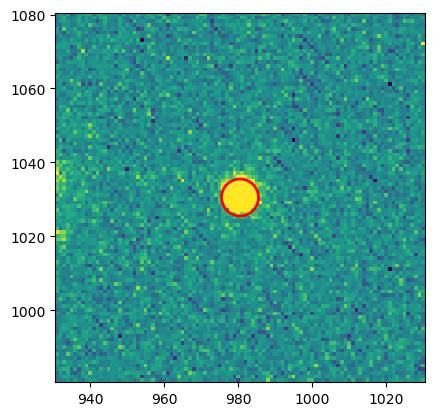

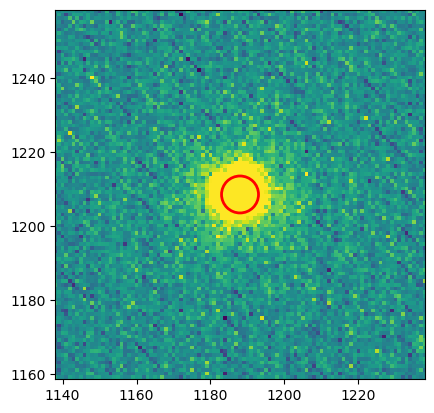

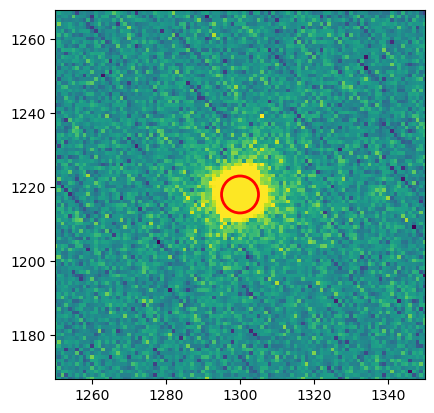

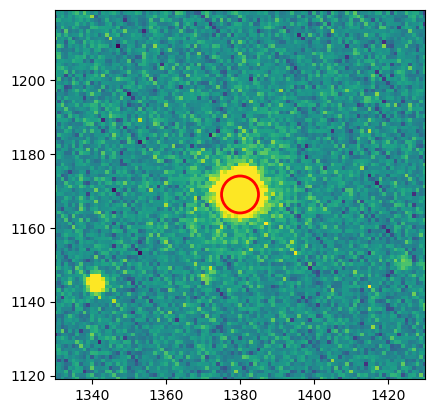

In [551]:
std_field_B= glob.glob(reduced_dir+"a206otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(980.5,1030.5), (1188,1208.5), (1300, 1218), (1380, 1169)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [552]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")

    V_list[i].append(m)

Instrumental Magnitude: -9.43806245479573
Instrumental Magnitude: -11.708953236632214
Instrumental Magnitude: -11.449958126467049
Instrumental Magnitude: -11.031283136536658


### R Filter

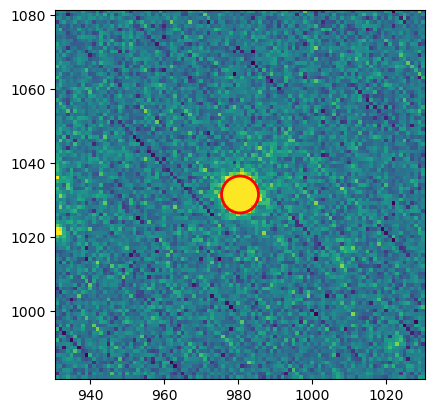

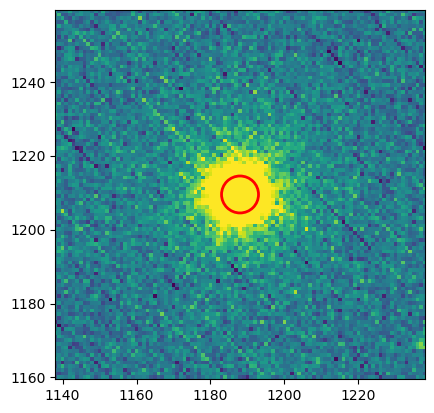

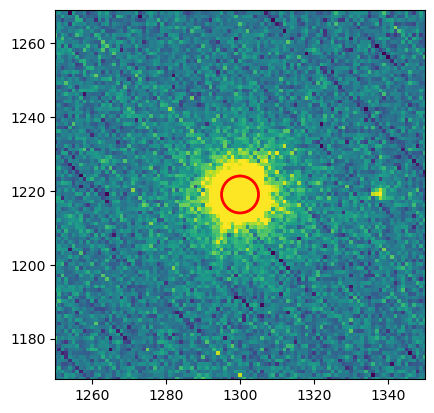

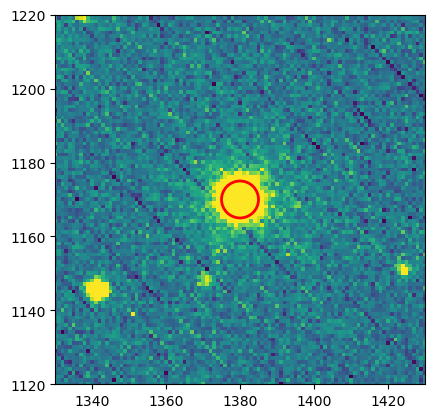

In [560]:
std_field_B= glob.glob(reduced_dir+"a208otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(980.5,1031.5), (1188,1209.5), (1300, 1219), (1380, 1170)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [561]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    R_list[i].append(m)

Instrumental Magnitude: -9.97096222739441
Instrumental Magnitude: -12.32949092078961
Instrumental Magnitude: -12.108190353588942
Instrumental Magnitude: -11.399542317577362


### I Filter

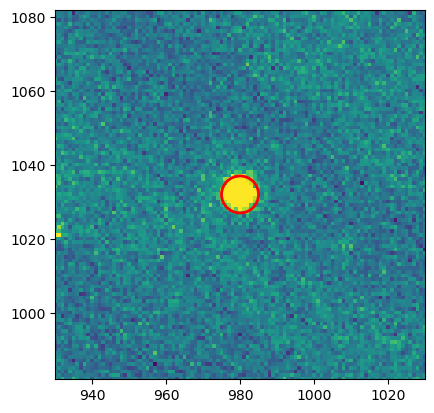

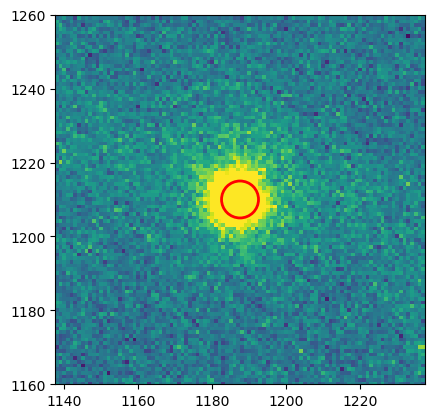

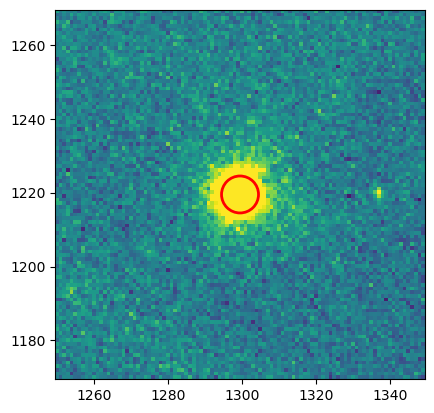

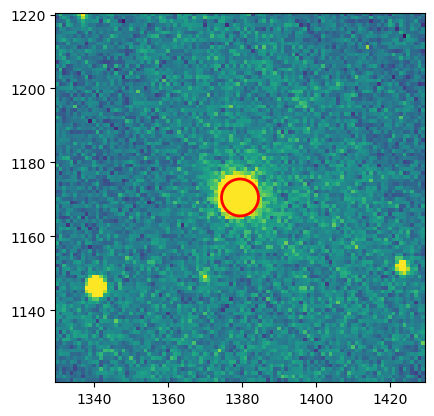

In [569]:
std_field_B= glob.glob(reduced_dir+"a210otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(980,1032), (1187.5,1210), (1299.5, 1219.5), (1379.5, 1170.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [570]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    I_list[i].append(m)

Instrumental Magnitude: -10.029208871594244
Instrumental Magnitude: -12.35668767727807
Instrumental Magnitude: -12.153453086896974
Instrumental Magnitude: -11.227775515083234


### 4th Epoch: X~2.20
U: a238.fits \
B: a240.fits \
V: a242.fits \
R: a244.fits \
I: a246.fits

### U Filter

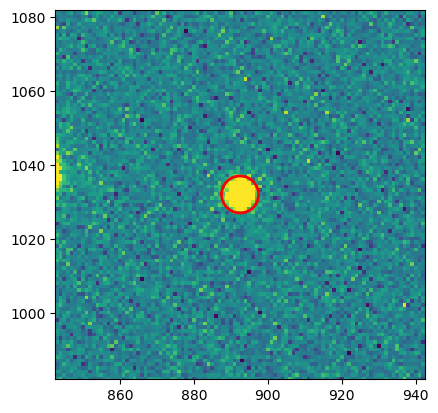

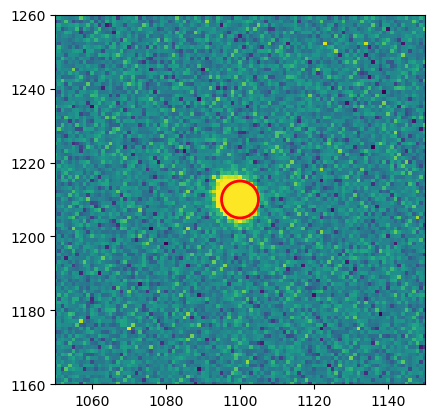

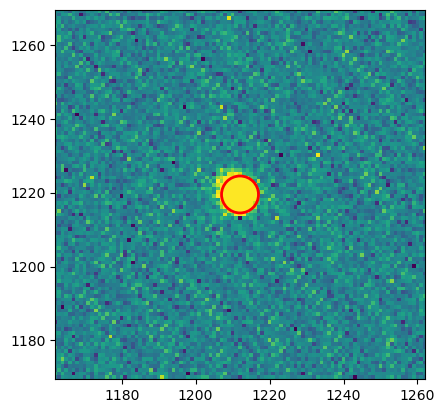

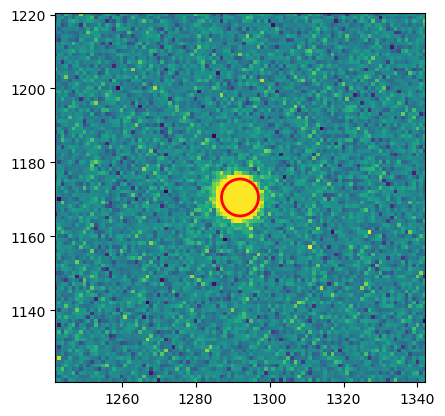

In [535]:
std_field_B= glob.glob(reduced_dir+"a238otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(892.5,1032), (1100,1210), (1212, 1219.5), (1292, 1170.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [536]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    U_list[i].append(m)

Instrumental Magnitude: -5.151760935984804
Instrumental Magnitude: -6.634025668387392
Instrumental Magnitude: -6.231331908286315
Instrumental Magnitude: -7.376330817694723


In [537]:
print(U_list)

[[-5.6490331909249045, -5.5660287139192395, -5.507536019330139, -5.151760935984804], [-7.1095170818361115, -7.07641082684318, -7.008224260141978, -6.634025668387392], [-6.705976104180092, -6.6530793993187185, -6.609453354036539, -6.231331908286315], [-7.840581239066403, -7.801168038368341, -7.734415808060199, -7.376330817694723]]


### B Filter

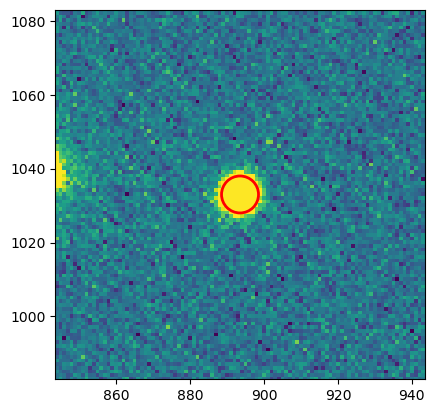

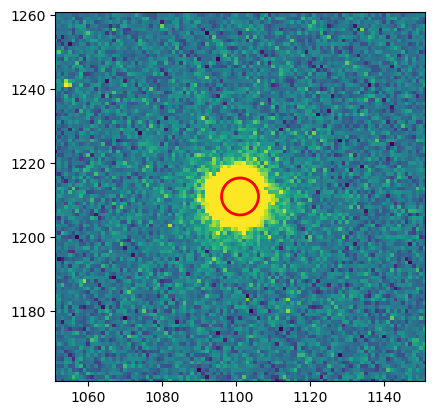

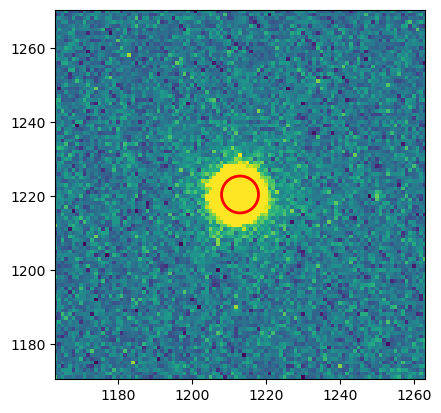

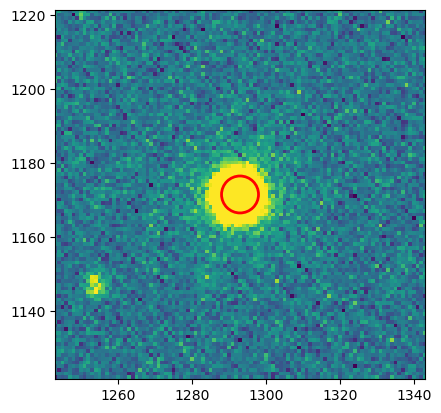

In [623]:
std_field_B= glob.glob(reduced_dir+"a239otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(893.5,1033), (1101,1211), (1213, 1220.5), (1293, 1171.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [625]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    B_list[i].append()

Instrumental Magnitude: -8.2559433536812
Instrumental Magnitude: -10.361454656224511
Instrumental Magnitude: -10.062495418667252
Instrumental Magnitude: -10.118123920488847


In [626]:
print(B_list)

[[-8.545751893808557, -8.476528777427108, -8.448750323687522, -8.2559433536812], [-10.65731624648464, -10.586191834143646, -10.573872172255491, -10.361454656224511], [-10.352169392944809, -10.286735853101447, -10.2683876807777, -10.062495418667252], [-10.417825244099756, -10.35226037889051, -10.329932954763471, -10.118123920488847]]


### V Filter

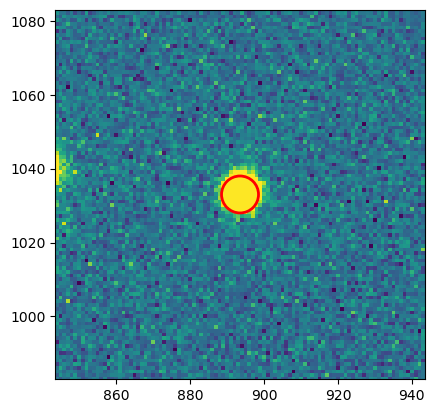

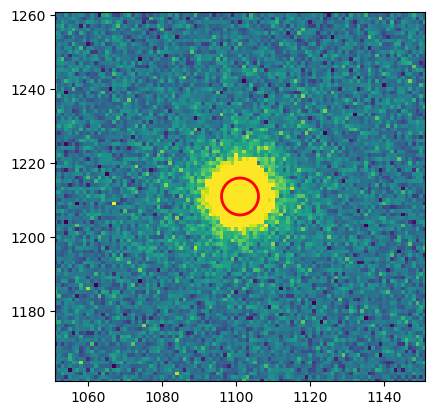

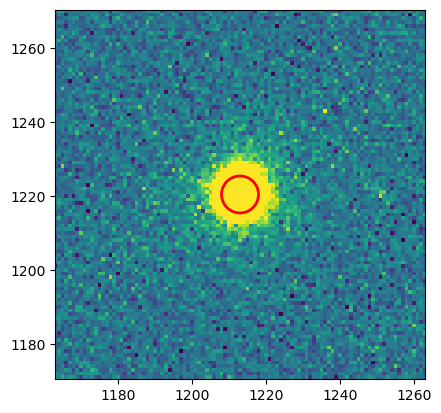

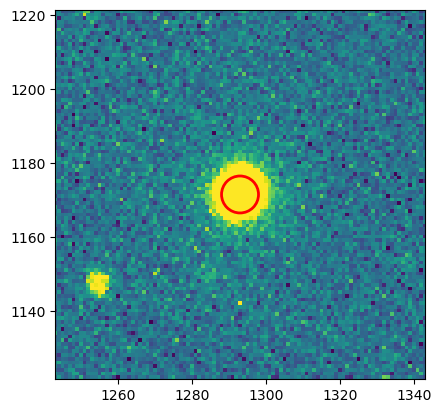

In [553]:
std_field_B= glob.glob(reduced_dir+"a242otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(893.5,1033), (1101,1211), (1213, 1220.5), (1293, 1171.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [554]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")

    V_list[i].append(m)

Instrumental Magnitude: -9.234822253903435
Instrumental Magnitude: -11.524825475676924
Instrumental Magnitude: -11.269469140668303
Instrumental Magnitude: -10.843563771452285


In [555]:
print(V_list)

[[-9.44680085784704, -9.454018612021063, -9.43806245479573, -9.234822253903435], [-11.723259834588436, -11.721842858687193, -11.708953236632214, -11.524825475676924], [-11.459806471820793, -11.467469418502274, -11.449958126467049, -11.269469140668303], [-11.036171954110202, -11.045838434343692, -11.031283136536658, -10.843563771452285]]


### R Filter

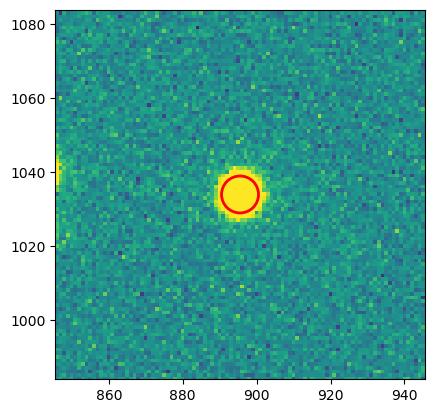

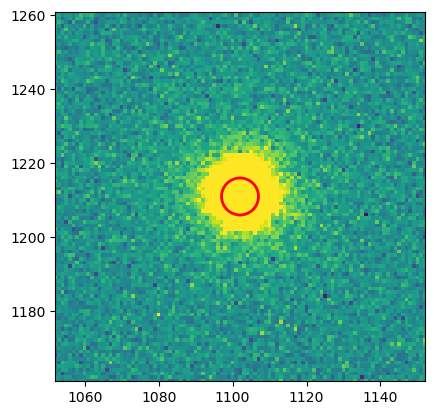

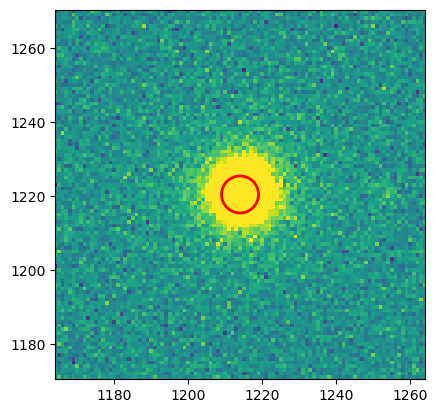

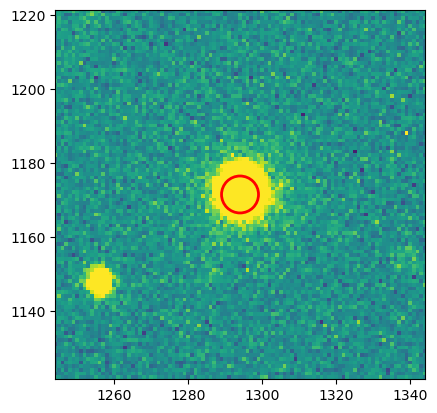

In [562]:
std_field_B= glob.glob(reduced_dir+"a244otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(895.5,1034), (1102,1211), (1214, 1220.5), (1294, 1171.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [563]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    R_list[i].append(m)

Instrumental Magnitude: -9.737967103272178
Instrumental Magnitude: -12.088647289902816
Instrumental Magnitude: -11.868347310500788
Instrumental Magnitude: -11.155891109509495


In [564]:
print(R_list)

[[-9.953362413952476, -9.975844504111187, -9.97096222739441, -9.737967103272178], [-12.318643884146281, -12.343252384008272, -12.32949092078961, -12.088647289902816], [-12.089346596767065, -12.116121476905448, -12.108190353588942, -11.868347310500788], [-11.35844006788427, -11.401295337014858, -11.399542317577362, -11.155891109509495]]


### I Filter

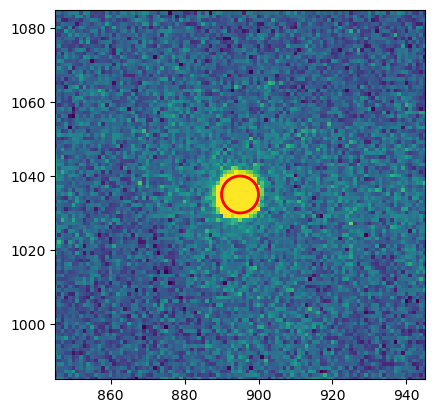

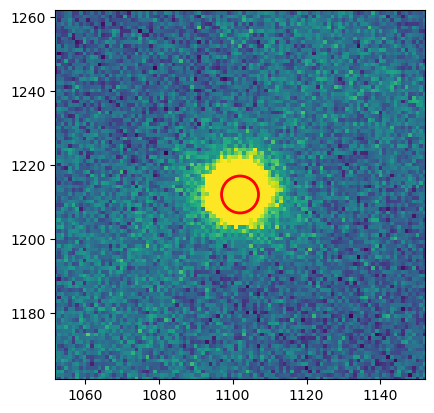

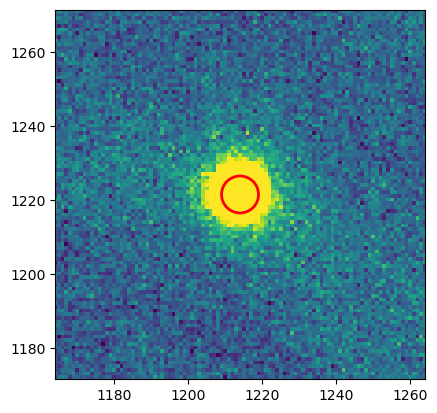

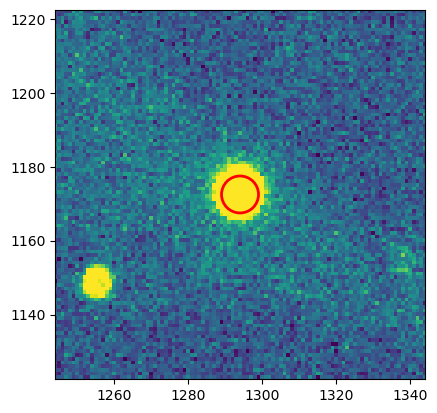

In [572]:
std_field_B= glob.glob(reduced_dir+"a246otzf.fits")
hdu=fits.open(std_field_B[0])
image=fits.getdata(std_field_B[0])

landolt_positions = [(895,1035), (1102,1212), (1214, 1221.5), (1294, 1172.5)] # these were selected trhough visual inspection

for i in range(len(landolt_positions)):
        aperture = CircularAperture(landolt_positions, r=5)
        #annulus_aperture = CircularAnnulus(landolt_positions, r_in=40, r_out=50)

        vmin, vmax= interval.get_limits(image)
        plt.imshow(image, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
        plt.xlim(landolt_positions[i][0]-50, landolt_positions[i][0]+50)
        plt.ylim(landolt_positions[i][1]-50, landolt_positions[i][1]+50)

        ap_patches = aperture.plot(color='red', lw=2,
                                label='Photometry aperture')
        #ann_patches = annulus_aperture.plot(color='red', lw=2, label='Background annulus')
        #handles = (ap_patches[0])#, ann_patches[0])
        #plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
                #handles=handles, prop={'weight': 'bold', 'size': 11})
        plt.show()

In [573]:
# -----------------------
# Inputs
# -----------------------
radius = 5                                  # choose one aperture radius
r_in, r_out = 30, 35                         # background annulus
exptime = hdu[0].header['EXPTIME']                              # exposure time in seconds



# -----------------------
# Aperture + annulus
# -----------------------
aperture = CircularAperture(landolt_positions, r=radius)
annulus = CircularAnnulus(landolt_positions, r_in=r_in, r_out=r_out)

for i in range(len(landolt_positions)):
#Total Signal from source in aperature
    phot_table = aperture_photometry(image, aperture)
    len
    T=phot_table[i]['aperture_sum']

    #Get areas
    A_circle= aperture.area
    A_annulus= annulus.area

    # Total counts in annulus
    total_B= aperture_photometry(image, annulus)[i]['aperture_sum']
    B= total_B/A_annulus



    # Convert to instrumental magnitudes
    m=-2.5*np.log10((T-A_circle*B)/exptime)

    print(f"Instrumental Magnitude: {m}")
    I_list[i].append(m)

Instrumental Magnitude: -9.789996156960962
Instrumental Magnitude: -12.160603919530708
Instrumental Magnitude: -11.97749685793591
Instrumental Magnitude: -11.026472294372782


In [574]:
print(I_list)

[[-9.988796115645108, -10.027219269506897, -10.029208871594244, -9.789996156960962], [-12.356271482234654, -12.360925889188138, -12.35668767727807, -12.160603919530708], [-12.142446656012766, -12.174602954959635, -12.153453086896974, -11.97749685793591], [-11.19459498211655, -11.22001230721823, -11.227775515083234, -11.026472294372782]]


## Plotting: Instrumental magnitude vs. Airmass

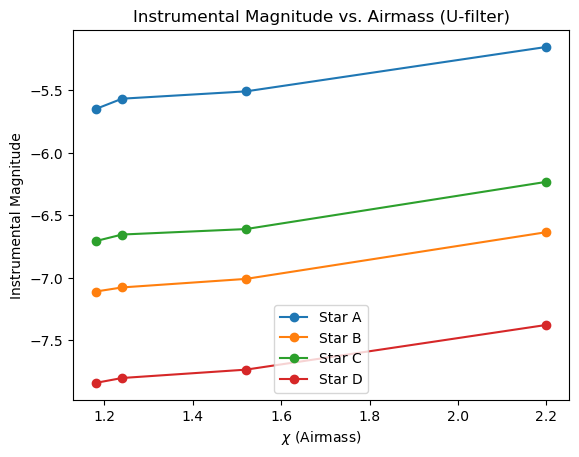

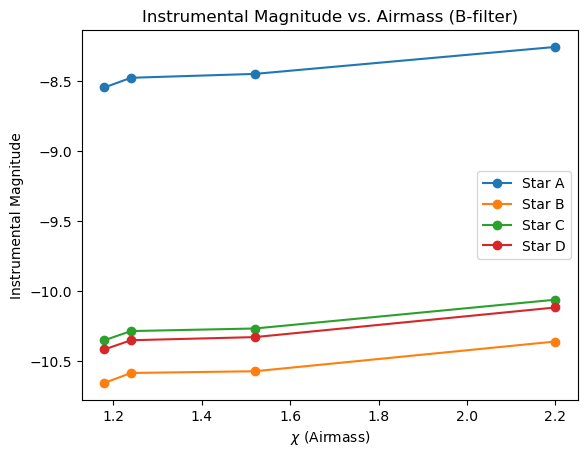

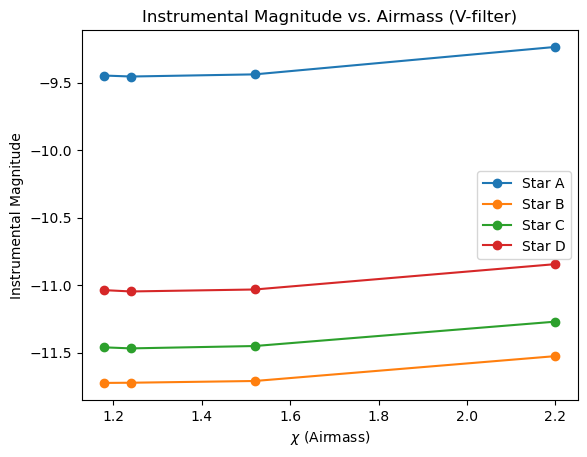

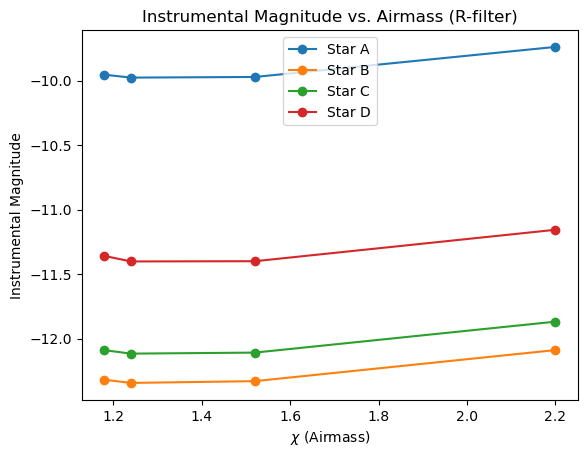

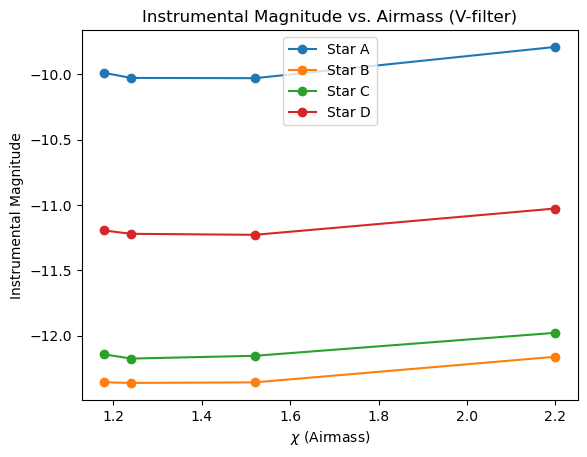

In [627]:
X_list=[1.18,1.24, 1.52, 2.20]
plt.plot(X_list, U_list[0] , '-o', label='Star A')
plt.plot(X_list, U_list[1] , '-o', label='Star B')
plt.plot(X_list, U_list[2] , '-o', label='Star C')
plt.plot(X_list, U_list[3] , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel('Instrumental Magnitude')
plt.title('Instrumental Magnitude vs. Airmass (U-filter)')
plt.legend()
plt.show()

plt.plot(X_list, B_list[0] , '-o', label='Star A')
plt.plot(X_list, B_list[1] , '-o', label='Star B')
plt.plot(X_list, B_list[2] , '-o', label='Star C')
plt.plot(X_list, B_list[3] , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel('Instrumental Magnitude')
plt.title('Instrumental Magnitude vs. Airmass (B-filter)')
plt.legend()
plt.show()

plt.plot(X_list, V_list[0] , '-o', label='Star A')
plt.plot(X_list, V_list[1] , '-o', label='Star B')
plt.plot(X_list, V_list[2] , '-o', label='Star C')
plt.plot(X_list, V_list[3] , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel('Instrumental Magnitude')
plt.title('Instrumental Magnitude vs. Airmass (V-filter)')
plt.legend()
plt.show()

plt.plot(X_list, R_list[0] , '-o', label='Star A')
plt.plot(X_list, R_list[1] , '-o', label='Star B')
plt.plot(X_list, R_list[2] , '-o', label='Star C')
plt.plot(X_list, R_list[3] , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel('Instrumental Magnitude')
plt.title('Instrumental Magnitude vs. Airmass (R-filter)')
plt.legend()
plt.show()

plt.plot(X_list, I_list[0] , '-o', label='Star A')
plt.plot(X_list, I_list[1] , '-o', label='Star B')
plt.plot(X_list, I_list[2] , '-o', label='Star C')
plt.plot(X_list, I_list[3] , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel('Instrumental Magnitude')
plt.title('Instrumental Magnitude vs. Airmass (V-filter)')
plt.legend()
plt.show()

## Plotting: (Instrumental magnitude - Correct magnitude) vs. Airmass

In [767]:
#Setting up correct magnitudes
#V-band manitudes
V_A=15.256
V_B=12.969
V_C=13.229
V_D=13.691

#All bands
Star_A=[0.32+(0.873+V_A),0.873+ V_A, V_A, V_A-(0.505), V_A-(1.015)]
Star_B=[1.007+(1.081+V_B),1.081+ V_B, V_B, V_B-(0.590), V_B-(1.090)]
Star_C=[1.138+(1.134+V_C),1.134+ V_C, V_C, V_C-(0.618), V_C-(1.138)]
Star_D=[-0.025+(0.535+V_D),0.535+ V_D, V_D, V_D-(0.324), V_D-(0.650)]

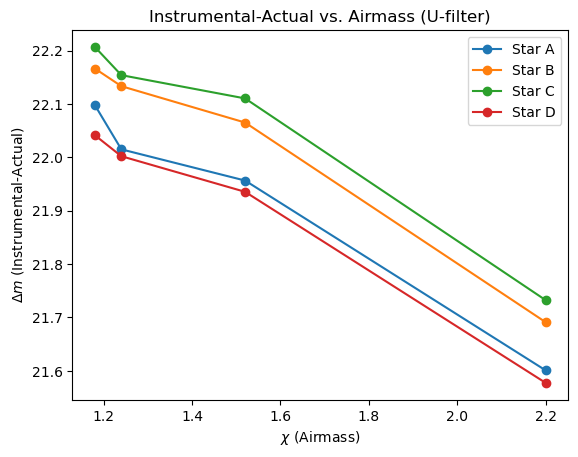

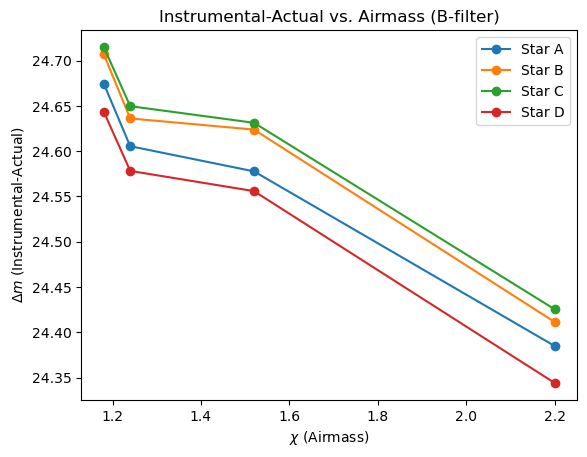

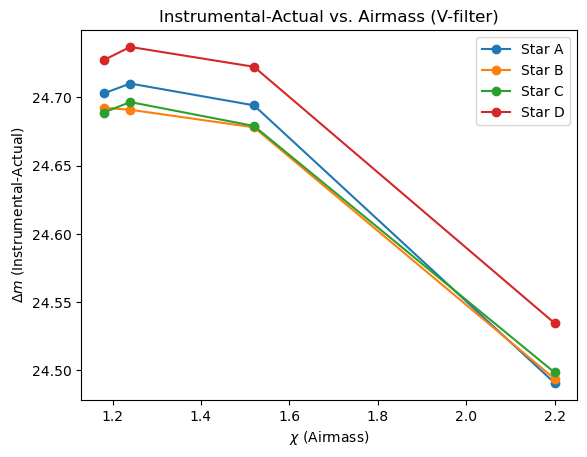

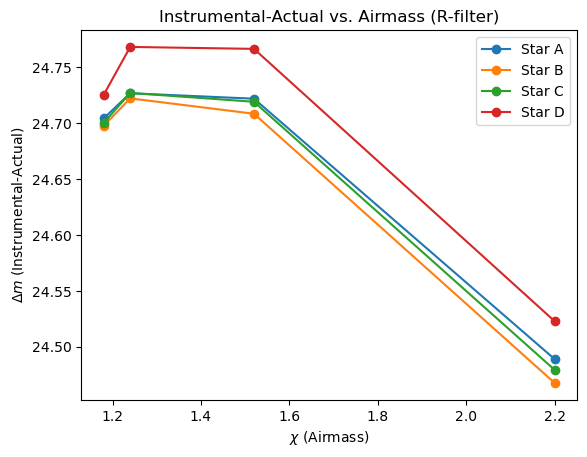

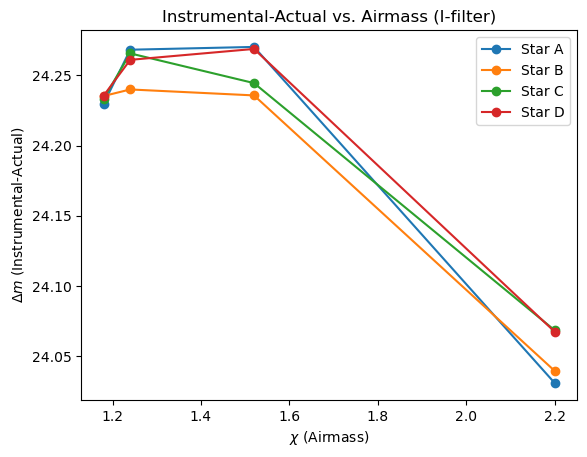

In [768]:
X_list=[1.18,1.24, 1.52, 2.20]

#U filter
plt.plot(X_list, np.abs(U_list[0]-np.ones(4)*Star_A[0]) , '-o', label='Star A')
plt.plot(X_list, np.abs(U_list[1]-np.ones(4)*Star_B[0]), '-o', label='Star B')
plt.plot(X_list, np.abs(U_list[2]-np.ones(4)*Star_C[0]), '-o', label='Star C')
plt.plot(X_list, np.abs(U_list[3]-np.ones(4)*Star_D[0]) , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m$ (Instrumental-Actual)')
plt.title('Instrumental-Actual vs. Airmass (U-filter)')
plt.legend()
plt.show()

#B filter
plt.plot(X_list, np.abs(B_list[0]-np.ones(4)*Star_A[1]), '-o', label='Star A')
plt.plot(X_list, np.abs(B_list[1]-np.ones(4)*Star_B[1]) , '-o', label='Star B')
plt.plot(X_list, np.abs(B_list[2]-np.ones(4)*Star_C[1]), '-o', label='Star C')
plt.plot(X_list, np.abs(B_list[3]-np.ones(4)*Star_D[1]) , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m$ (Instrumental-Actual)')
plt.title('Instrumental-Actual vs. Airmass (B-filter)')
plt.legend()
plt.show()

#V filter
plt.plot(X_list, np.abs(V_list[0]-np.ones(4)*Star_A[2]) , '-o', label='Star A')
plt.plot(X_list, np.abs(V_list[1]-np.ones(4)*Star_B[2]), '-o', label='Star B')
plt.plot(X_list, np.abs(V_list[2]-np.ones(4)*Star_C[2]) , '-o', label='Star C')
plt.plot(X_list, np.abs(V_list[3]-np.ones(4)*Star_D[2]) , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m$ (Instrumental-Actual)')
plt.title('Instrumental-Actual vs. Airmass (V-filter)')
plt.legend()
plt.show()

#R filter
plt.plot(X_list, np.abs(R_list[0]-np.ones(4)*Star_A[3]), '-o', label='Star A')
plt.plot(X_list, np.abs(R_list[1]-np.ones(4)*Star_B[3]) , '-o', label='Star B')
plt.plot(X_list, np.abs(R_list[2]-np.ones(4)*Star_C[3]) , '-o', label='Star C')
plt.plot(X_list, np.abs(R_list[3]-np.ones(4)*Star_D[3]) , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m$ (Instrumental-Actual)')
plt.title('Instrumental-Actual vs. Airmass (R-filter)')
plt.legend()
plt.show()

#I filter
plt.plot(X_list, np.abs(I_list[0]-np.ones(4)*Star_A[4]) , '-o', label='Star A')
plt.plot(X_list, np.abs(I_list[1]-np.ones(4)*Star_B[4]) , '-o', label='Star B')
plt.plot(X_list, np.abs(I_list[2]-np.ones(4)*Star_C[4]) , '-o', label='Star C')
plt.plot(X_list, np.abs(I_list[3]-np.ones(4)*Star_D[4]) , '-o', label='Star D')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m$ (Instrumental-Actual)')
plt.title('Instrumental-Actual vs. Airmass (I-filter)')
plt.legend()
plt.show()

## Fitting: (Instrumental magnitude - Actual magntiude) vs. Airmass

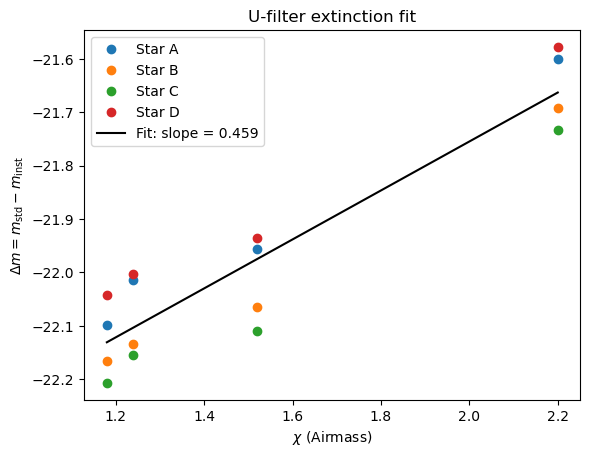

U-filter extinction coefficient k = 0.4588
U-filter zero point/intercept b = -22.6723


In [629]:
#U filter
delta_A = U_list[0] - np.ones(4)*Star_A[0]
delta_B = U_list[1] - np.ones(4)*Star_B[0]
delta_C = U_list[2] - np.ones(4)*Star_C[0]
delta_D = U_list[3] - np.ones(4)*Star_D[0]

# Combine all points into one fit
x = np.concatenate([X_list, X_list, X_list, X_list])
y = np.concatenate([delta_A, delta_B, delta_C, delta_D])

# Least-squares linear fit: y = k*x + b
k, b = np.polyfit(x, y, 1)

# Plot
xfit = np.linspace(np.min(x), np.max(x), 100)
yfit = k * xfit + b

plt.plot(X_list, delta_A, 'o', label='Star A')
plt.plot(X_list, delta_B, 'o', label='Star B')
plt.plot(X_list, delta_C, 'o', label='Star C')
plt.plot(X_list, delta_D, 'o', label='Star D')
plt.plot(xfit, yfit, 'k-', label=f'Fit: slope = {k:.3f}')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('U-filter extinction fit')
plt.legend()
plt.show()

print(f"U-filter extinction coefficient k = {k:.4f}")
print(f"U-filter zero point/intercept b = {b:.4f}")

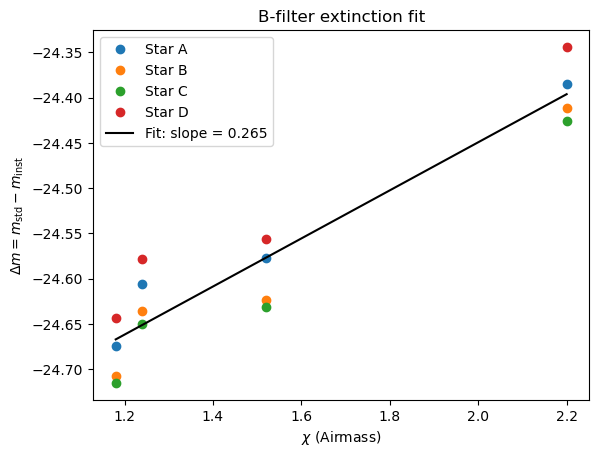

V-filter extinction coefficient k = 0.2655
V-filter zero point/intercept b = -24.9804


In [630]:
#B filter
delta_A = B_list[0] - np.ones(4)*Star_A[1]
delta_B = B_list[1] - np.ones(4)*Star_B[1]
delta_C = B_list[2] - np.ones(4)*Star_C[1]
delta_D = B_list[3] - np.ones(4)*Star_D[1]

# Combine all points into one fit
x = np.concatenate([X_list, X_list, X_list, X_list])
y = np.concatenate([delta_A, delta_B, delta_C, delta_D])

# Least-squares linear fit: y = k*x + b
k, b = np.polyfit(x, y, 1)

# Plot
xfit = np.linspace(np.min(x), np.max(x), 100)
yfit = k * xfit + b

plt.plot(X_list, delta_A, 'o', label='Star A')
plt.plot(X_list, delta_B, 'o', label='Star B')
plt.plot(X_list, delta_C, 'o', label='Star C')
plt.plot(X_list, delta_D, 'o', label='Star D')
plt.plot(xfit, yfit, 'k-', label=f'Fit: slope = {k:.3f}')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('B-filter extinction fit')
plt.legend()
plt.show()

print(f"V-filter extinction coefficient k = {k:.4f}")
print(f"V-filter zero point/intercept b = {b:.4f}")

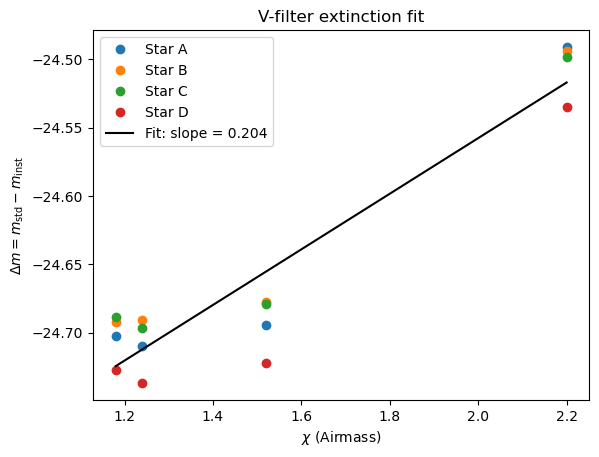

V-filter extinction coefficient k = 0.2036
V-filter zero point/intercept b = -24.9648


In [631]:
#V filter
delta_A = V_list[0] - np.ones(4)*Star_A[2]
delta_B = V_list[1] - np.ones(4)*Star_B[2]
delta_C = V_list[2] - np.ones(4)*Star_C[2]
delta_D = V_list[3] - np.ones(4)*Star_D[2]

# Combine all points into one fit
x = np.concatenate([X_list, X_list, X_list, X_list])
y = np.concatenate([delta_A, delta_B, delta_C, delta_D])

# Least-squares linear fit: y = k*x + b
k, b = np.polyfit(x, y, 1)

# Plot
xfit = np.linspace(np.min(x), np.max(x), 100)
yfit = k * xfit + b

plt.plot(X_list, delta_A, 'o', label='Star A')
plt.plot(X_list, delta_B, 'o', label='Star B')
plt.plot(X_list, delta_C, 'o', label='Star C')
plt.plot(X_list, delta_D, 'o', label='Star D')
plt.plot(xfit, yfit, 'k-', label=f'Fit: slope = {k:.3f}')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('V-filter extinction fit')
plt.legend()
plt.show()

print(f"V-filter extinction coefficient k = {k:.4f}")
print(f"V-filter zero point/intercept b = {b:.4f}")

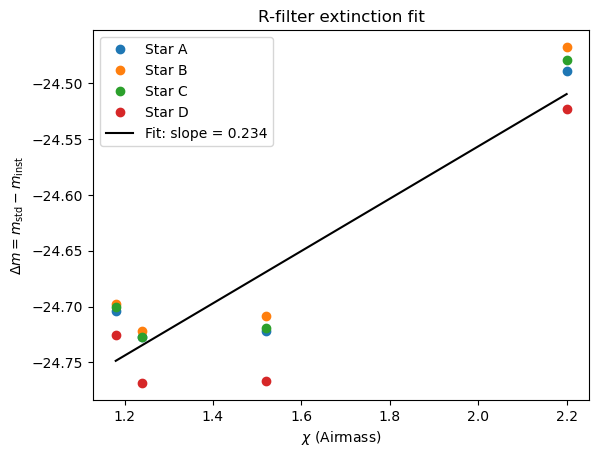

R-filter extinction coefficient k = 0.2340
R-filter zero point/intercept b = -25.0247


In [632]:
#R filter
delta_A = R_list[0] - np.ones(4)*Star_A[3]
delta_B = R_list[1] - np.ones(4)*Star_B[3]
delta_C = R_list[2] - np.ones(4)*Star_C[3]
delta_D = R_list[3] - np.ones(4)*Star_D[3]

# Combine all points into one fit
x = np.concatenate([X_list, X_list, X_list, X_list])
y = np.concatenate([delta_A, delta_B, delta_C, delta_D])

# Least-squares linear fit: y = k*x + b
k, b = np.polyfit(x, y, 1)

# Plot
xfit = np.linspace(np.min(x), np.max(x), 100)
yfit = k * xfit + b

plt.plot(X_list, delta_A, 'o', label='Star A')
plt.plot(X_list, delta_B, 'o', label='Star B')
plt.plot(X_list, delta_C, 'o', label='Star C')
plt.plot(X_list, delta_D, 'o', label='Star D')
plt.plot(xfit, yfit, 'k-', label=f'Fit: slope = {k:.3f}')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('R-filter extinction fit')
plt.legend()
plt.show()

print(f"R-filter extinction coefficient k = {k:.4f}")
print(f"R-filter zero point/intercept b = {b:.4f}")

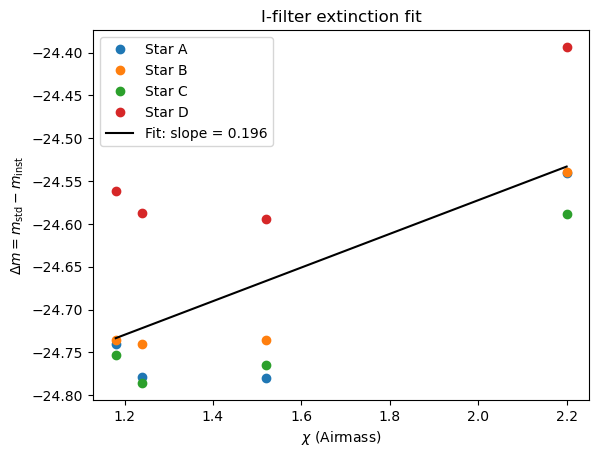

I-filter extinction coefficient k = 0.1963
I-filter zero point/intercept b = -24.9650


In [633]:
#I filter
delta_A = I_list[0] - np.ones(4)*Star_A[3]
delta_B = I_list[1] - np.ones(4)*Star_B[3]
delta_C = I_list[2] - np.ones(4)*Star_C[3]
delta_D = I_list[3] - np.ones(4)*Star_D[3]

# Combine all points into one fit
x = np.concatenate([X_list, X_list, X_list, X_list])
y = np.concatenate([delta_A, delta_B, delta_C, delta_D])

# Least-squares linear fit: y = k*x + b
k, b = np.polyfit(x, y, 1)

# Plot
xfit = np.linspace(np.min(x), np.max(x), 100)
yfit = k * xfit + b

plt.plot(X_list, delta_A, 'o', label='Star A')
plt.plot(X_list, delta_B, 'o', label='Star B')
plt.plot(X_list, delta_C, 'o', label='Star C')
plt.plot(X_list, delta_D, 'o', label='Star D')
plt.plot(xfit, yfit, 'k-', label=f'Fit: slope = {k:.3f}')

plt.xlabel(r'$\chi$ (Airmass)')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('I-filter extinction fit')
plt.legend()
plt.show()

print(f"I-filter extinction coefficient k = {k:.4f}")
print(f"I-filter zero point/intercept b = {b:.4f}")

## Tabulated Results (for Problem 5)

### Extinction 
| Band | Zero point (ZP) | Extinction Coefficent   |
|------|------------------|------------------------|
| U    | -22.6723         | 0.4588                 |
| B    | -24.9804         | 0.2655                 |
| V    | -24.9648         | 0.2036                 |
| R    | -25.0247         | 0.2340                 |
| I    | -24.9650         | 0.1963                 |

$\textbf{Discussion:}$ Extinction affects shorter, bluer wavlengths (like the U-band) more than longer, redder wavelengths (like the R-band). Therefore the increasing trend of the extinction coefficent checks out!

### Problem 6

After extinction correcting your standard stars to zero airmasses (i.e., you’re correcting
to the top of the atmosphere), make a plot of the difference between real magnitudes and
instrumental magnitudes using your standard stars as a function of V−R color and B−V
color. Fit a linear relation to this trend. The fit gives you your instrumental zero points
and the first order color term which let you transform your instrumental photometry to
the standard system. Tabulate the instrumental zero point and first order color terms for
each band in a neat, digestible way.

$\textbf{Logical Rundown:}$ To correct for the atmospheric extinction I subtacted the product of the extinction coefficient ($k_{filter}$) and the airmass ($\chi$) from the instrumental magnitude. Then I find the difference between the real magnitudes and the extinction corrected instrumental magnitudes iterated for each of the filters ($U,B,V,R,I$) and plot it against (V-R) and then (B-V) and fit each of these plots using the same method as Problem 5

### Fitting the Instrumental Zero Point and Color Term for (V-R)

[0.505 0.59  0.618 0.324]
[0.505 0.505 0.505 0.505 0.59  0.59  0.59  0.59  0.618 0.618 0.618 0.618
 0.324 0.324 0.324 0.324]
(16,)
(16,)
[-5.6490331909249045, -5.5660287139192395, -5.507536019330139, -5.151760935984804]
[-6.19041719 -6.13494071 -6.20491202 -6.16112094]


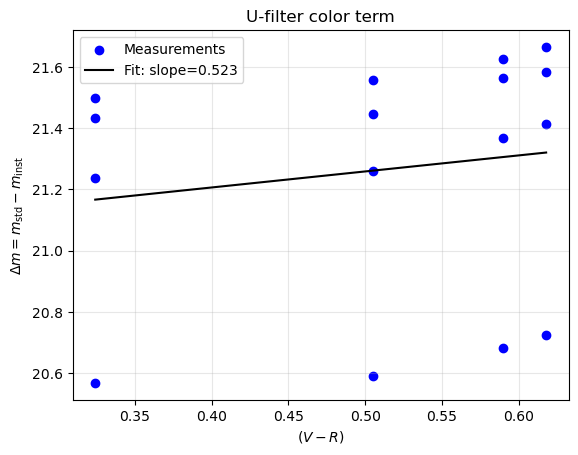

U-filter color coefficient: 0.5232459980550548
U-filter intercept: 20.997208560889153


In [764]:
# Fitting for U filter
k_U= 0.4588#U-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass


color = np.array([
    Star_A[2] - Star_A[3],
    Star_B[2] - Star_B[3],
    Star_C[2] - Star_C[3],
    Star_D[2] - Star_D[3]
])
print(color)
x = np.repeat(color, 4)
print(x)
y = np.array([
    Star_A[0] - np.array(U_list[0]),
    Star_B[0] - np.array(U_list[1]),
    Star_C[0] - np.array(U_list[2]),
    Star_D[0] - np.array(U_list[3])
]).flatten()

print(np.shape(x))
print(np.shape(y))

#correct for extinction
print(U_list[0])
print(np.array(U_list[0]) -k_U*np.array(X_list))
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('U-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("U-filter color coefficient:", m)
print("U-filter intercept:", b)

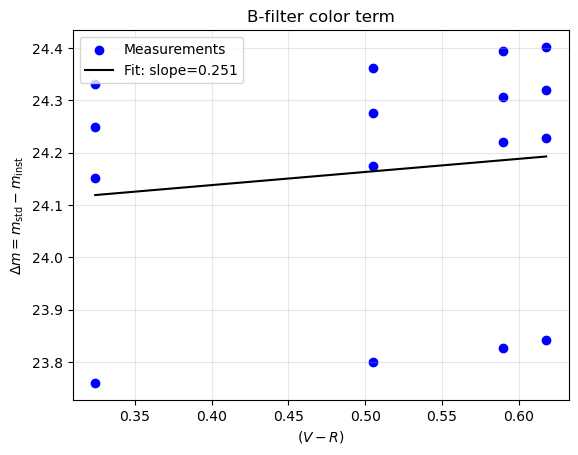

B-filter color coefficient: 0.2505604903960727
B-filter intercept: 24.037718326606203


In [711]:
# Fitting for B filter
k_B= 0.2655 #B-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass

color = np.array([
    Star_A[2] - Star_A[3],
    Star_B[2] - Star_B[3],
    Star_C[2] - Star_C[3],
    Star_D[2] - Star_D[3]
])

x = np.repeat(color, 4)
y = np.array([
    Star_A[1] - np.array(B_list[0]),
    Star_B[1] - np.array(B_list[1]),
    Star_C[1] - np.array(B_list[2]),
    Star_D[1] - np.array(B_list[3])
]).flatten()

#correct for extinction
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('B-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("B-filter color coefficient:", m)
print("B-filter intercept:", b)

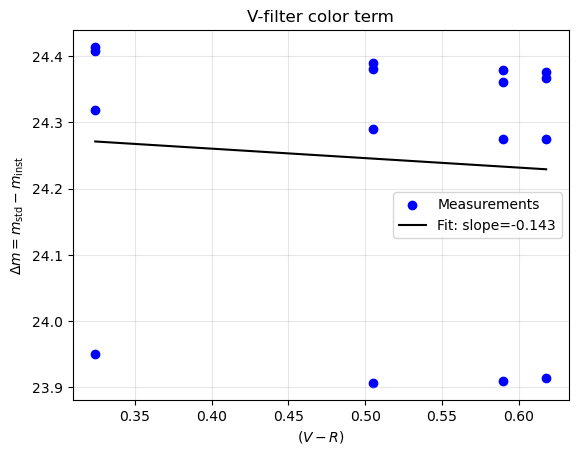

V-filter color coefficient: -0.14273369865079363
V-filter intercept: 24.317403763416237


In [712]:
# Fitting for V filter
k_V= 0.2036 #V-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass

color = np.array([
    Star_A[2] - Star_A[3],
    Star_B[2] - Star_B[3],
    Star_C[2] - Star_C[3],
    Star_D[2] - Star_D[3]
])

x = np.repeat(color, 4)
y = np.array([
    Star_A[2] - np.array(V_list[0]),
    Star_B[2] - np.array(V_list[1]),
    Star_C[2] - np.array(V_list[2]),
    Star_D[2] - np.array(V_list[3])
]).flatten()

#correct for extinction
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('V-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("V-filter color coefficient:", m)
print("V-filter intercept:", b)

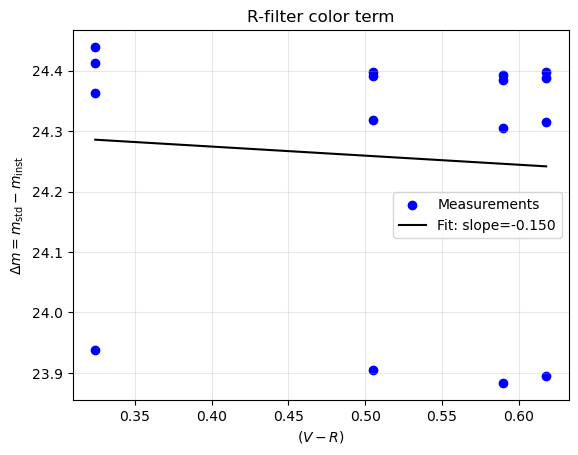

R-filter color coefficient: -0.14996937818343886
R-filter intercept: 24.334288486922755


In [714]:
# Fitting for R filter
k_R= 0.2340 #R-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass

color = np.array([
    Star_A[2] - Star_A[3],
    Star_B[2] - Star_B[3],
    Star_C[2] - Star_C[3],
    Star_D[2] - Star_D[3]
])

x = np.repeat(color, 4)
y = np.array([
    Star_A[3] - np.array(R_list[0]),
    Star_B[3] - np.array(R_list[1]),
    Star_C[3] - np.array(R_list[2]),
    Star_D[3] - np.array(R_list[3])
]).flatten()

#correct for extinction
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('R-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("R-filter color coefficient:", m)
print("R-filter intercept:", b)

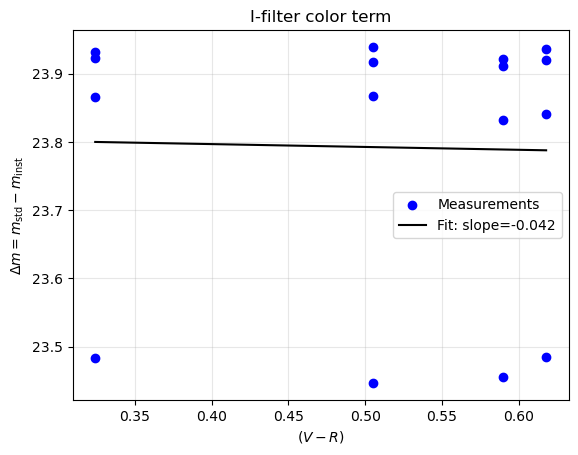

I-filter color coefficient: -0.04164625959507656
I-filter intercept: 23.81332610998222


In [ ]:
# Fitting for I filter
k_B= 0.1963 #I-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass

color = np.array([
    Star_A[2] - Star_A[3],
    Star_B[2] - Star_B[3],
    Star_C[2] - Star_C[3],
    Star_D[2] - Star_D[3]
])

x = np.repeat(color, 4)
y = np.array([
    Star_A[4] - np.array(I_list[0]),
    Star_B[4] - np.array(I_list[1]),
    Star_C[4] - np.array(I_list[2]),
    Star_D[4] - np.array(I_list[3])
]).flatten()

#correct for extinction
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('I-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("I-filter color coefficient:", m)
print("I-filter intercept:", b)

### Finding the Instrumental Zero Point and Color Term for (B-V)

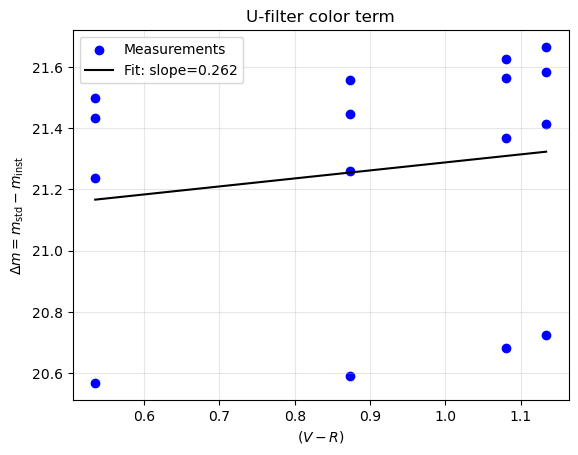

U-filter color coefficient: 0.2615862699050962
U-filter intercept: 21.026739821432145


In [717]:
# Fitting for U filter
k_U= 0.4588#U-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass


color = np.array([
    Star_A[1] - Star_A[2],
    Star_B[1] - Star_B[2],
    Star_C[1] - Star_C[2],
    Star_D[1] - Star_D[2]
])

x = np.repeat(color, 4)
y = np.array([
    Star_A[0] - np.array(U_list[0]),
    Star_B[0] - np.array(U_list[1]),
    Star_C[0] - np.array(U_list[2]),
    Star_D[0] - np.array(U_list[3])
]).flatten()

#correct for extinction
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('U-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("U-filter color coefficient:", m)
print("U-filter intercept:", b)

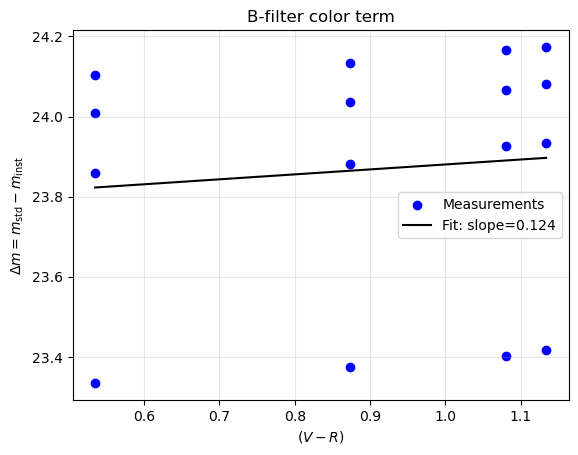

B-filter color coefficient: 0.12359140292803998
B-filter intercept: 23.75665784313833


In [718]:
# Fitting for B filter
k_B= 0.2655 #B-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass

color = np.array([
    Star_A[1] - Star_A[2],
    Star_B[1] - Star_B[2],
    Star_C[1] - Star_C[2],
    Star_D[1] - Star_D[2]
])

x = np.repeat(color, 4)
y = np.array([
    Star_A[1] - np.array(B_list[0]),
    Star_B[1] - np.array(B_list[1]),
    Star_C[1] - np.array(B_list[2]),
    Star_D[1] - np.array(B_list[3])
]).flatten()

#correct for extinction
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('B-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("B-filter color coefficient:", m)
print("B-filter intercept:", b)

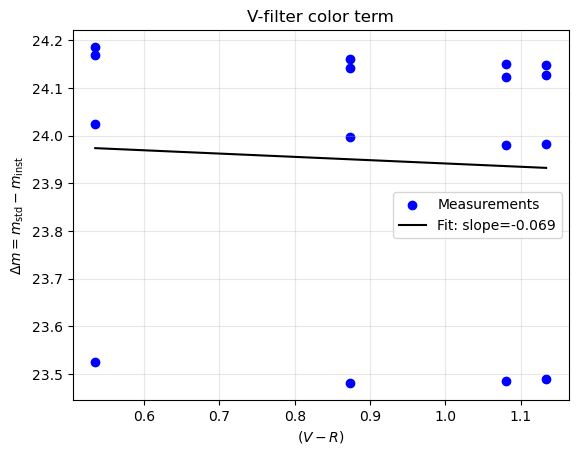

V-filter color coefficient: -0.06907138095527145
V-filter intercept: 24.010562530678566


In [719]:
# Fitting for V filter
k_V= 0.2036 #V-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass

color = np.array([
    Star_A[1] - Star_A[2],
    Star_B[1] - Star_B[2],
    Star_C[1] - Star_C[2],
    Star_D[1] - Star_D[2]
])

x = np.repeat(color, 4)
y = np.array([
    Star_A[2] - np.array(V_list[0]),
    Star_B[2] - np.array(V_list[1]),
    Star_C[2] - np.array(V_list[2]),
    Star_D[2] - np.array(V_list[3])
]).flatten()

#correct for extinction
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('V-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("V-filter color coefficient:", m)
print("V-filter intercept:", b)

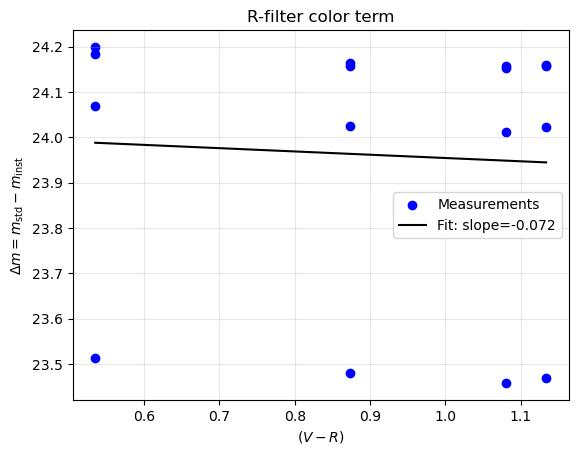

R-filter color coefficient: -0.07234268123245545
R-filter intercept: 24.026725464609132


In [720]:
# Fitting for R filter
k_R= 0.2340 #R-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass

color = np.array([
    Star_A[1] - Star_A[2],
    Star_B[1] - Star_B[2],
    Star_C[1] - Star_C[2],
    Star_D[1] - Star_D[2]
])

x = np.repeat(color, 4)
y = np.array([
    Star_A[3] - np.array(R_list[0]),
    Star_B[3] - np.array(R_list[1]),
    Star_C[3] - np.array(R_list[2]),
    Star_D[3] - np.array(R_list[3])
]).flatten()

#correct for extinction
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('R-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("R-filter color coefficient:", m)
print("R-filter intercept:", b)

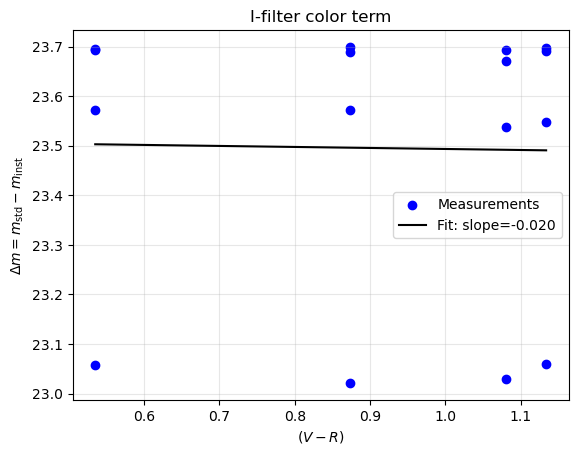

I-filter color coefficient: -0.020436329077562022
I-filter intercept: 23.51391245734543


In [721]:
# Fitting for I filter
k_B= 0.1963 #I-band extinction coefficent

X = np.tile(np.array(X_list), 4) #airmass

color = np.array([
    Star_A[1] - Star_A[2],
    Star_B[1] - Star_B[2],
    Star_C[1] - Star_C[2],
    Star_D[1] - Star_D[2]
])

x = np.repeat(color, 4)
y = np.array([
    Star_A[4] - np.array(I_list[0]),
    Star_B[4] - np.array(I_list[1]),
    Star_C[4] - np.array(I_list[2]),
    Star_D[4] - np.array(I_list[3])
]).flatten()

#correct for extinction
y_corr = y - k_U * X

m, b = np.polyfit(x, y_corr, 1)

xfit = np.linspace(x.min(), x.max(), 100)
y_fit = m * xfit + b

plt.scatter(x, y_corr, color='blue', label='Measurements')

# Best-fit line
plt.plot(xfit, y_fit, 'k-', label=f'Fit: slope={m:.3f}')

plt.xlabel(r'$(V-R)$')
plt.ylabel(r'$\Delta m = m_{\rm std} - m_{\rm inst}$')
plt.title('I-filter color term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("I-filter color coefficient:", m)
print("I-filter intercept:", b)

## Tabulated Results (for Problem 6)

### (V-R) Color
| Band | Zero point (ZP) | First-order color term |
|------|------------------|------------------------|
| U    | 20.9972          | 0.5232                 |
| B    | 24.0377          | 0.2506                 |
| V    | 24.3174          | -0.1427                |
| R    | 24.3342          | -0.1500                |
| I    | 23.8133          | -0.0416                |

### (B-V) Color
| Band | Zero point (ZP) | First-order color term |
|------|------------------|------------------------|
| U    | 21.0267          | 0.2616                 |
| B    | 23.7567          | 0.1236                 |
| V    | 24.0106          | -0.0691                |
| R    | 24.0267          | -0.0723                |
| I    | 23.5139          | -0.0204                |

### Problem 7

Using the extinction terms and color terms derived for the imaging dataset previously, do
photometry on the stars in NGC6823 and make a color magnitude diagram of this open
cluster. Either V vs. B−V or R vs. R−I are the most common ones you might find, but
there may be others in the literature and you are welcome to follow their lead.


$\textbf{Logical Rundown:}$ First I used star finder for a B-band and V-band exposure of NGC6832. Then I matched the sources that were common between both exposures where I set a speration threshold of 3 pixels to match both star finder lists. For all the objects that were matched I calculated the instrumental magnitude for B-band and V-band, then using the correction coefficients and Zero Point magnitude calculated in Problems 5 and 6 I was able to correct the insturmental magnitudes to more realistic, calibrated magntitudes. With these magnitudes I was then able to create a color-magnitude diagram.

In [ ]:
#Identify stars with DAO Star Finder for B band 
std_field_B= glob.glob(reduced_dir+"a160otzf.fits")
exptime_B=12 #exposure time from log.txt
image_B=fits.getdata(std_field_B[0])

mean, median, std = sigma_clipped_stats(image_B, sigma=3.0)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*std)

sources_B = daofind(image_B - median)
for col in sources_B.colnames:
    if col not in ('id', 'npix'):
        sources_B[col].info.format = '%.2f'  # for consistent table output
sources_B.pprint(max_width=76)

 id xcentroid ycentroid sharpness roundness1 ... sky    peak   flux   mag 
--- --------- --------- --------- ---------- ... ---- ------- ------ -----
  1    933.51     -0.00      0.93      -0.78 ... 0.00 7675.49 105.92 -5.06
  2   1283.55      5.86      0.55      -0.44 ... 0.00  524.52   4.50 -1.63
  3   1126.90      6.78      0.63      -0.35 ... 0.00  217.62   1.96 -0.73
  4    260.95      8.96      0.38      -0.92 ... 0.00  118.70   1.71 -0.58
  5   1064.55     17.45      0.42      -0.95 ... 0.00  169.79   2.05 -0.78
  6   1839.81     21.82      0.53      -0.66 ... 0.00  257.34   2.59 -1.03
  7   1357.91     25.69      0.36      -0.93 ... 0.00  247.49   2.16 -0.83
  8    167.24     35.67      0.49      -0.75 ... 0.00 2948.47  28.52 -3.64
  9    427.02     36.15      0.64      -0.58 ... 0.00  111.24   1.15 -0.15
 10    847.16     38.04      0.54      -0.71 ... 0.00  320.02   3.19 -1.26
...       ...       ...       ...        ... ...  ...     ...    ...   ...
979   1941.73   2019.21  

In [ ]:
#Identify stars with DAO Star Finder for B band 
std_field_V= glob.glob(reduced_dir+"a159otzf.fits")
exptime_V=12 #exposure time from log.txt
image_V=fits.getdata(std_field_V[0])

mean, median, std = sigma_clipped_stats(image_V, sigma=3.0)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*std)

sources_V = daofind(image_V - median)
for col in sources_V.colnames:
    if col not in ('id', 'npix'):
        sources_V[col].info.format = '%.2f'  # for consistent table output
sources_V.pprint(max_width=76)

 id  xcentroid ycentroid sharpness roundness1 ... sky    peak   flux  mag 
---- --------- --------- --------- ---------- ... ---- ------- ----- -----
   1   1415.43      1.37      0.45      -0.87 ... 0.00  599.09  6.36 -2.01
   2   1129.03      7.52      0.42      -0.61 ... 0.00  716.86  6.19 -1.98
   3   1285.53      6.46      0.46      -0.67 ... 0.00 1672.98 14.79 -2.92
   4    396.10      9.63      0.32      -0.08 ... 0.00  129.33  1.49 -0.43
   5    262.91      9.61      0.47      -0.41 ... 0.00  529.14  5.01 -1.75
   6   1643.05      9.95      0.43      -0.72 ... 0.00  192.68  1.76 -0.61
   7   1777.50      9.90      0.43      -0.71 ... 0.00  276.99  2.52 -1.00
   8   2016.48      9.72      0.38      -0.99 ... 0.00  162.87  1.73 -0.59
   9    885.05     15.12      0.52      -0.53 ... 0.00  115.59  1.05 -0.05
  10    911.44     15.20      0.26      -0.75 ... 0.00  122.30  1.60 -0.51
 ...       ...       ...       ...        ... ...  ...     ...   ...   ...
1227    944.80   2025.36 

In [ ]:
pos_B = np.transpose((sources_B['xcentroid'], sources_B['ycentroid']))
pos_V = np.transpose((sources_V['xcentroid'], sources_V['ycentroid']))

[[ 9.33505416e+02 -4.30809083e-05]
 [ 1.28354678e+03  5.86287710e+00]
 [ 1.12690464e+03  6.78369433e+00]
 ...
 [ 1.92957603e+03  2.03505748e+03]
 [ 1.93193101e+03  2.03567280e+03]
 [ 1.26096486e+02  2.03673640e+03]]
[[1.41542575e+03 1.37330449e+00]
 [1.12902552e+03 7.52318379e+00]
 [1.28553029e+03 6.45934495e+00]
 ...
 [1.93320204e+03 2.03667135e+03]
 [1.77559212e+03 2.04401989e+03]
 [1.77588902e+03 2.04440178e+03]]


In [726]:
matches = []
max_dist = 3.0   # pixels; adjust if needed

for i, (xB, yB) in enumerate(pos_B):
    best_j = None
    best_dist = np.inf

    for j, (xV, yV) in enumerate(pos_V):
        dist = np.sqrt((xB - xV)**2 + (yB - yV)**2)
        if dist < best_dist:
            best_dist = dist
            best_j = j

    if best_dist < max_dist:
        matches.append((i, best_j, best_dist))

print(len(matches))

pos_B_match = np.array([pos_B[i] for i, j, d in matches])
pos_V_match = np.array([pos_V[j] for i, j, d in matches])

659


In [727]:
r = 5
r_in, r_out = 30, 35

ap_B = CircularAperture(pos_B_match, r=r)
an_B = CircularAnnulus(pos_B_match, r_in=r_in, r_out=r_out)

ap_V = CircularAperture(pos_V_match, r=r)
an_V = CircularAnnulus(pos_V_match, r_in=r_in, r_out=r_out)

phot_B = aperture_photometry(image_B, ap_B)
phot_V = aperture_photometry(image_V, ap_V)

bkg_B = aperture_photometry(image_B, an_B)
bkg_V = aperture_photometry(image_V, an_V)

aper_sum_B = np.array(phot_B["aperture_sum"])
aper_sum_V = np.array(phot_V["aperture_sum"])

bkg_sum_B = np.array(bkg_B["aperture_sum"])
bkg_sum_V = np.array(bkg_V["aperture_sum"])

aper_area = ap_B.area
ann_area = an_B.area

bkg_per_pix_B = bkg_sum_B / ann_area
bkg_per_pix_V = bkg_sum_V / ann_area

net_flux_B = aper_sum_B - aper_area * bkg_per_pix_B
net_flux_V = aper_sum_V - aper_area * bkg_per_pix_V

In [728]:
mB_inst = -2.5 * np.log10(net_flux_B / exptime_B)
mV_inst = -2.5 * np.log10(net_flux_V / exptime_V)

/tmp/ipykernel_9987/1239694324.py:1: RuntimeWarning: invalid value encountered in log10
  mB_inst = -2.5 * np.log10(net_flux_B / exptime_B)
/tmp/ipykernel_9987/1239694324.py:2: RuntimeWarning: invalid value encountered in log10
  mV_inst = -2.5 * np.log10(net_flux_V / exptime_V)


In [735]:
# Zero Point for extinction
ZP_B = 23.7567
ZP_V = 24.0106

#Extinction Coefficient
k_B = 0.2655   
k_V = 0.2036

#Color Term for (B-V) color
c_B = 0.1236 
c_V = -0.0691

In [770]:
airmass_NGC=1.09
color = ( (mB_inst - mV_inst) + (ZP_B - ZP_V) + (k_B * airmass_NGC - k_V * airmass_NGC) ) / (1 - c_B + c_V)

In [771]:
B_cal = mB_inst + ZP_B + k_B * airmass_NGC + c_B * color
V_cal = mV_inst + ZP_V + k_V * airmass_NGC + c_V * color

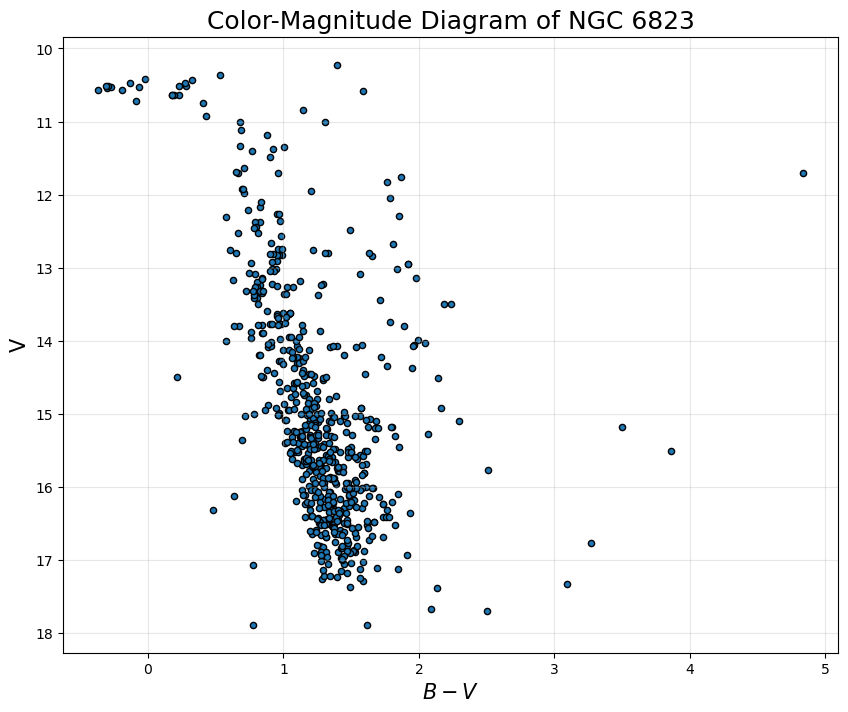

In [774]:
#good = np.isfinite(color) & np.isfinite(V_cal)

plt.figure(figsize=(10, 8))
plt.scatter(color, V_cal, s=20, edgecolor="k")

plt.gca().invert_yaxis()
plt.xlabel(r"$B - V$", fontsize=15)
plt.ylabel("V", fontsize=15)
plt.title("Color-Magnitude Diagram of NGC 6823", fontsize=18)
plt.grid(True, alpha=0.3)
plt.show()

$\textbf{Results (for Problem 7):}$ Yay I made a color-magnitude diagram! So science! :)